## Visualization of Plant Connectivity

In [29]:
import os
import sys
import numpy as np
# load files for each season
import pickle
import pandas as pd
sys.path.append('../scripts')
from utils import average_across_days, average_across_days_phiid

# Choose Ecosystem and Metric
ecosystem = 'LaurentianMapleGrove'  # 'GulfStLawrence', 'LaurentianMapleGrove'
metric = 'PhiID'  # 'PLV', 'coherence', 'transfer_entropy', 'wpli', 'imag_coherence'

if ecosystem == 'GulfStLawrence':
    from GulfStLawrence_info import seasons, SPRING, SUMMER, FALL, WINTER, plant_common_names_fr, plant_distances
else:
    from LaurentianMapleGrove_info import seasons, SPRING, SUMMER, FALL, WINTER, plant_common_names_fr, plant_distances

df_all_seasons = []
for SEASON in [SPRING, SUMMER, FALL, WINTER]:
    try:
        with open(f'../plant_data_{ecosystem}/{seasons[SEASON]}/connectivity_results_{metric}.pkl', 'rb') as f:
            dfs_results = pickle.load(f)
            if metric == 'PhiID':
                df_combined, df_avg = average_across_days_phiid(dfs_results)
            else:
                df_combined, df_avg = average_across_days(dfs_results, metric=metric)
            df_avg["Season"] = SEASON
            df_all_seasons.append(df_avg)
    except FileNotFoundError:
        print(f"File not found for season {seasons[SEASON]}. Skipping...")
        continue

# Sum transfer entropy at each epoch for each season
df_all_seasons_combined = pd.concat(df_all_seasons, ignore_index=True)
df_all_seasons_combined = pd.concat(df_all_seasons, ignore_index=True)

# Standardize to title case
df_all_seasons_combined = df_all_seasons_combined.rename(columns={
    'epoch': 'Epoch',
    'plant': 'Plant'
})
# Convert epochs to hours
total_epochs = df_all_seasons_combined["Epoch"].max() + 1  # Assuming epochs span 24 hours
df_all_seasons_combined["Hour"] = df_all_seasons_combined["Epoch"] / total_epochs * 24

if "Season_mapped" not in df_all_seasons_combined.columns:
    df_all_seasons_combined["Season_mapped"] = df_all_seasons_combined["Season"].map(seasons)

season_colors = {
    human_name: color
    for (_, human_name), color in zip(seasons.items(),
                                      ["#2ca02c", "#ffcc00", "#ff7f0e", "#1f77b4"])
}
plant_names = {i: name for i, name in enumerate(plant_common_names_fr.values())}

In [95]:
plant_names

{0: 'Érable rouge',
 1: 'Thé du Labrador',
 2: 'Fougère mâle',
 3: 'Polystic en épi',
 4: 'Aulne',
 5: 'Benoîte des ruisseaux',
 6: 'Gale odorante',
 7: 'Érable à épis'}

In [63]:
season_colors

{'Spring 2024': '#2ca02c',
 'Summer 2024': '#ffcc00',
 'Fall 2024': '#ff7f0e',
 'Winter 2024': '#1f77b4'}

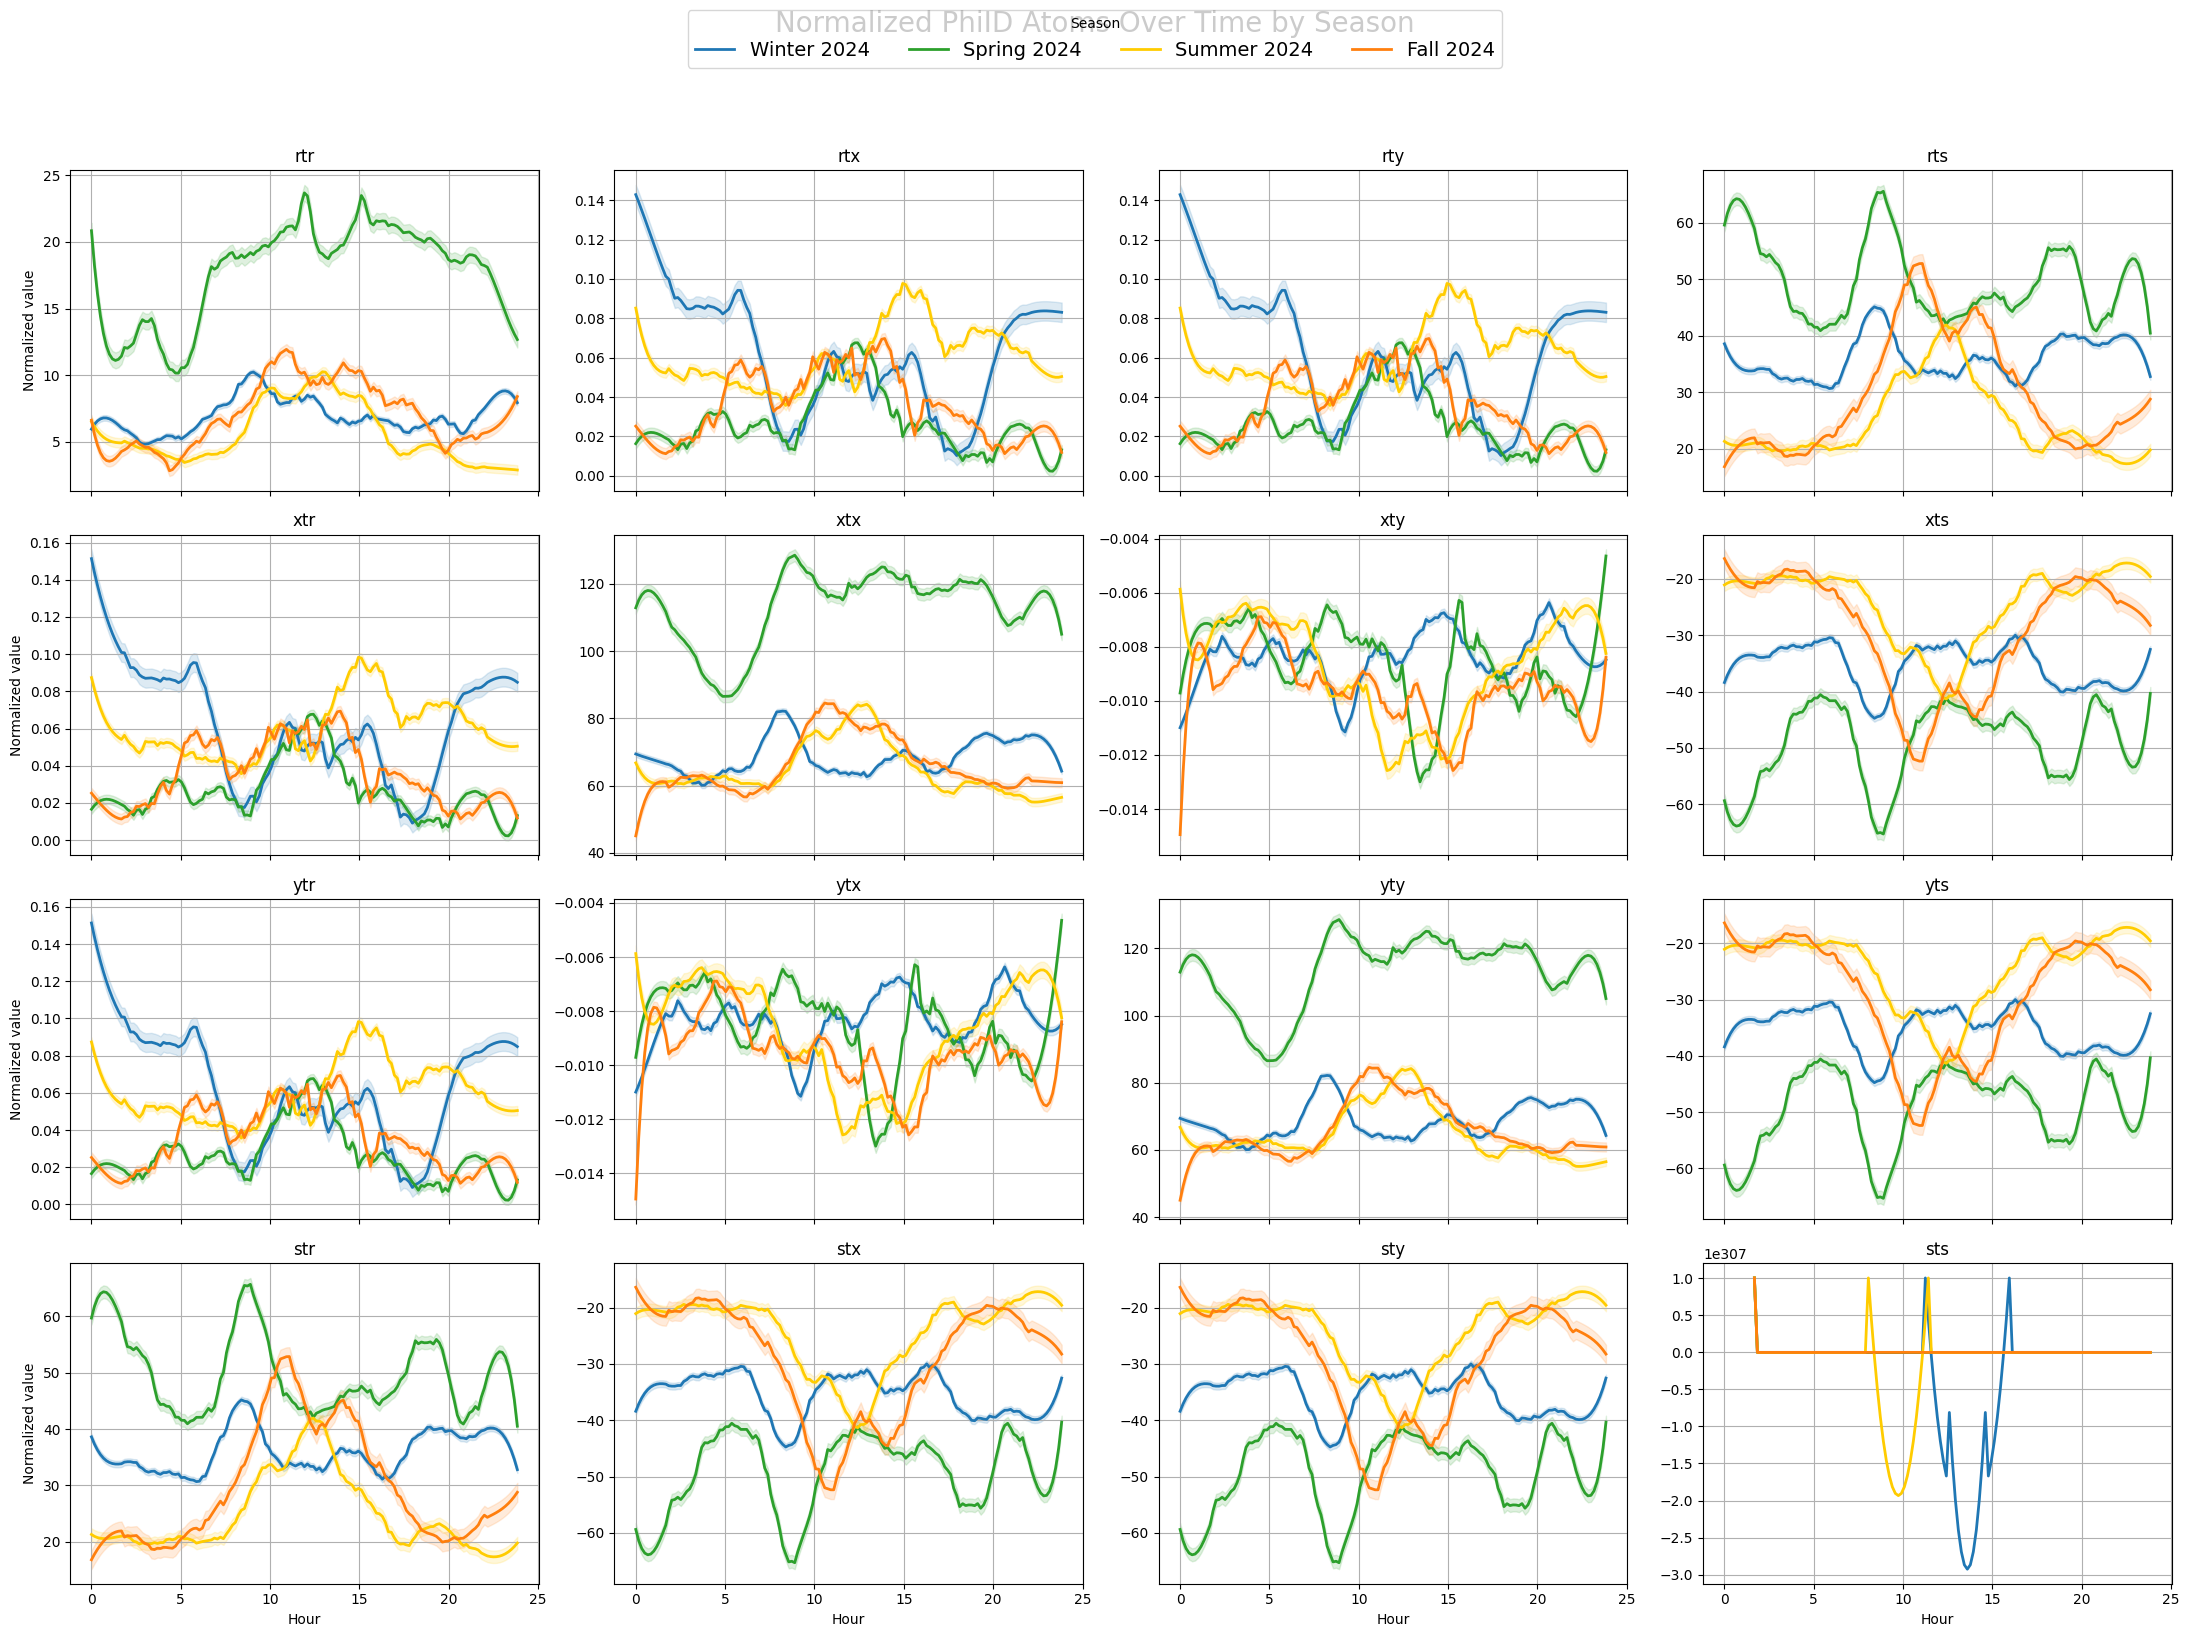

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# List all 16 atom names in the order of your columns
atom_names = [
    "rtr", "rtx", "rty", "rts",
    "xtr", "xtx", "xty", "xts",
    "ytr", "ytx", "yty", "yts",
    "str", "stx", "sty", "sts"
]

# 1) Ensure Hour column exists
total_epochs = df_all_seasons_combined["Epoch"].max() + 1
df_all_seasons_combined["Hour"] = df_all_seasons_combined["Epoch"] / total_epochs * 24

# 2) Compute N_max = P*(P-1)
plants = np.union1d(df_all_seasons_combined["Plant1"].unique(),
                    df_all_seasons_combined["Plant2"].unique())
N_max = len(plants) * (len(plants) - 1)

# 3) Extract and sort season names
season_names = list(seasons.values())
season_index = {"Winter":0, "Spring":1, "Summer":2, "Fall":3}
season_order = sorted(
    season_names,
    key=lambda nm: (int(nm.split()[1]), season_index[nm.split()[0]])
)

# 4) Assign your custom colors in that order
colors = ["#2ca02c", "#ffcc00", "#ff7f0e", "#1f77b4", ]
color_map = season_colors.copy()

# 5) Plot all atoms (one subplot per atom)
fig, axes = plt.subplots(4, 4, figsize=(22, 16), sharex=True)
axes = axes.flatten()

for i, atom in enumerate(atom_names):
    ax = axes[i]
    for season in season_order:
        sub = df_all_seasons_combined[df_all_seasons_combined["Season_mapped"] == season]
        # Group by Epoch, sum/calculate atom, then normalize
        sum_atom   = sub.groupby("Epoch")[atom].sum()
        count_atom = sub.groupby("Epoch")[atom].count()
        normalized_atom = (sum_atom / count_atom) * N_max

        # Clean up NaNs, smooth only if enough points
        norm_vals = normalized_atom.values
        mask = ~np.isnan(norm_vals)
        if mask.sum() < 7:  # Not enough points to smooth
            continue
        window = min(21, mask.sum() if mask.sum() % 2 == 1 else mask.sum()-1)
        if window < 5: window = 5
        smoothed = savgol_filter(np.nan_to_num(norm_vals), window_length=window, polyorder=3)

        ci    = 1.96 * np.std(smoothed) / np.sqrt(len(smoothed))
        lower = smoothed - ci
        upper = smoothed + ci
        hours = normalized_atom.index / total_epochs * 24

        ax.plot(hours, smoothed,
                color=color_map[season],
                linewidth=2,
                label=season if i == 0 else None)
        ax.fill_between(hours, lower, upper,
                        color=color_map[season],
                        alpha=0.15)

    ax.set_title(atom)
    ax.grid(True)
    if i % 4 == 0:
        ax.set_ylabel("Normalized value")
    if i >= 12:
        ax.set_xlabel("Hour")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, fontsize=14, title="Season")
fig.suptitle("Normalized PhiID Atoms Over Time by Season", fontsize=20, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()



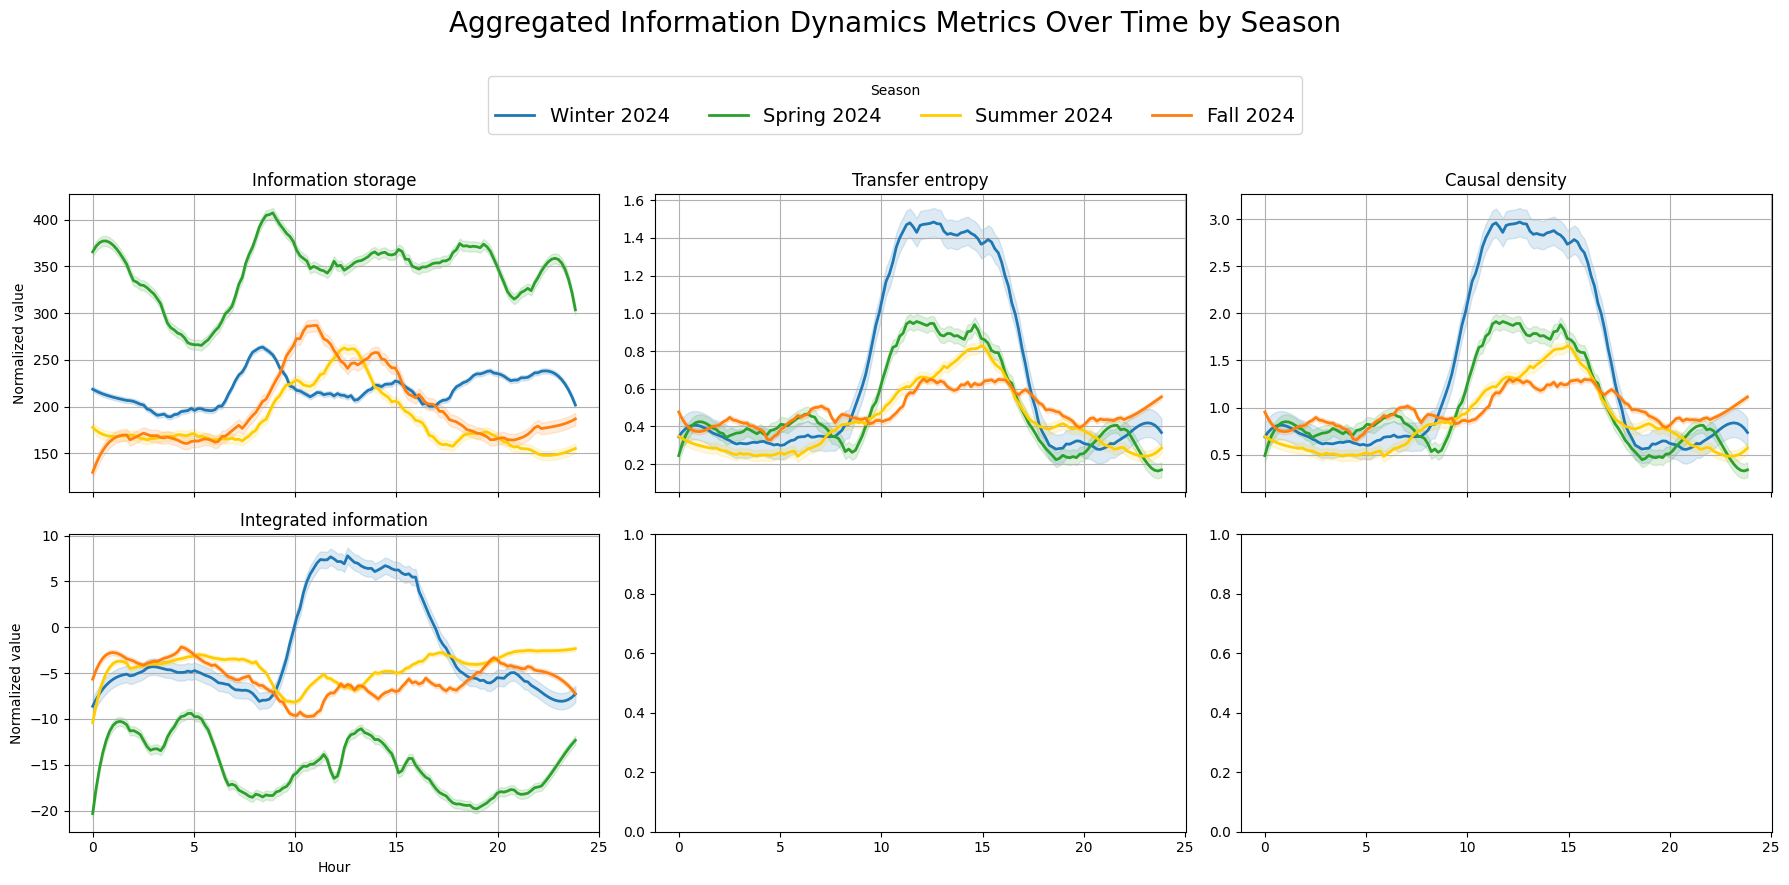

In [31]:
information_dynamics_metrics = {
    "Storage": ["rtr", "xtx", "yty", "sts"],
    "Copy": ["xtx", "yty"],
    "Transfer": ["xty", "ytx"],
    "Erasure": ["rtx", "rty"],
    "Downward causation": ["sty", "stx", "str"],
    "Upward causation": ["xts", "yts", "rts"],
}

IIT_metrics = {
    "Information storage": ["xtx", "yty", "rtr", "sts"],
    "Transfer entropy": ["xty", "xtr", "str", "sty"],
    "Causal density": ["xtr", "ytr", "sty", "str", "str", "xty", "ytx", "stx"],
    "Integrated information": ["rts", "xts", "sts", "sty", "str", "yts", "ytx", "stx", "xty"],
}

import numpy as np

def compute_aggregate_metrics(df, metric_dict):
    """
    Adds columns for each high-level metric in metric_dict,
    summing atom components (skipping NaNs) and cleaning up
    infinities before aggregation. For "Integrated information",
    subtracts 'rtr' from the sum.
    """
    df = df.copy()
    # 1. Clean ALL relevant atom columns first (in-place)
    all_atom_cols = set(sum(metric_dict.values(), []))
    for col in all_atom_cols:
        if col in df.columns:
            df[col] = df[col].replace([np.inf, -np.inf], np.nan)

    # 2. Aggregate new metric columns
    for met, atoms in metric_dict.items():
        atoms_present = [a for a in atoms if a in df.columns]
        # Sum, skipping NaN, but set NaN if all missing
        metric_sum = df[atoms_present].sum(axis=1, skipna=True)
        all_nan = df[atoms_present].isna().all(axis=1)
        metric_sum[all_nan] = np.nan

        # Special logic for IIT integrated information
        if met.lower() == "integrated information" and "rtr" in df.columns:
            # Subtract 'rtr', but if either is NaN, keep as NaN
            metric_sum = metric_sum - df["rtr"]
            # Optional: if you want to strictly enforce NaN if either is NaN
            metric_sum[metric_sum.isna() | df["rtr"].isna()] = np.nan

        df[met] = metric_sum

    return df

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# Pick which metric set you want (information_dynamics_metrics or IIT_metrics)
metric_dict = IIT_metrics
metric_names = list(metric_dict.keys())

# Add the aggregate columns
df_atoms = df_all_seasons_combined
df_metrics = compute_aggregate_metrics(df_atoms, metric_dict)

# Compute N_max as before
plants = np.union1d(df_metrics["Plant1"].unique(),
                    df_metrics["Plant2"].unique())
N_max = len(plants) * (len(plants) - 1)
total_epochs = df_metrics["Epoch"].max() + 1

# Plot
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)
axes = axes.flatten()

for i, metric in enumerate(metric_names):
    ax = axes[i]
    for season in season_order:
        sub = df_metrics[df_metrics["Season_mapped"] == season]
        sum_val   = sub.groupby("Epoch")[metric].sum()
        count_val = sub.groupby("Epoch")[metric].count()
        normalized = (sum_val / count_val) * N_max

        # Clean up NaNs, smooth only if enough points
        norm_vals = normalized.values
        mask = ~np.isnan(norm_vals)
        if mask.sum() < 7:  # Not enough points to smooth
            continue
        window = min(21, mask.sum() if mask.sum() % 2 == 1 else mask.sum()-1)
        if window < 5: window = 5
        smoothed = savgol_filter(np.nan_to_num(norm_vals), window_length=window, polyorder=3)

        ci    = 1.96 * np.std(smoothed) / np.sqrt(len(smoothed))
        lower = smoothed - ci
        upper = smoothed + ci
        hours = normalized.index / total_epochs * 24

        ax.plot(hours, smoothed,
                color=color_map[season],
                linewidth=2,
                label=season if i == 0 else None)
        ax.fill_between(hours, lower, upper,
                        color=color_map[season],
                        alpha=0.15)

    ax.set_title(metric)
    ax.grid(True)
    if i % 3 == 0:
        ax.set_ylabel("Normalized value")
    if i >= 3:
        ax.set_xlabel("Hour")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, fontsize=14, title="Season", bbox_to_anchor=(0.5, 1.03))
fig.suptitle("Aggregated Information Dynamics Metrics Over Time by Season", fontsize=20, y=1.1)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


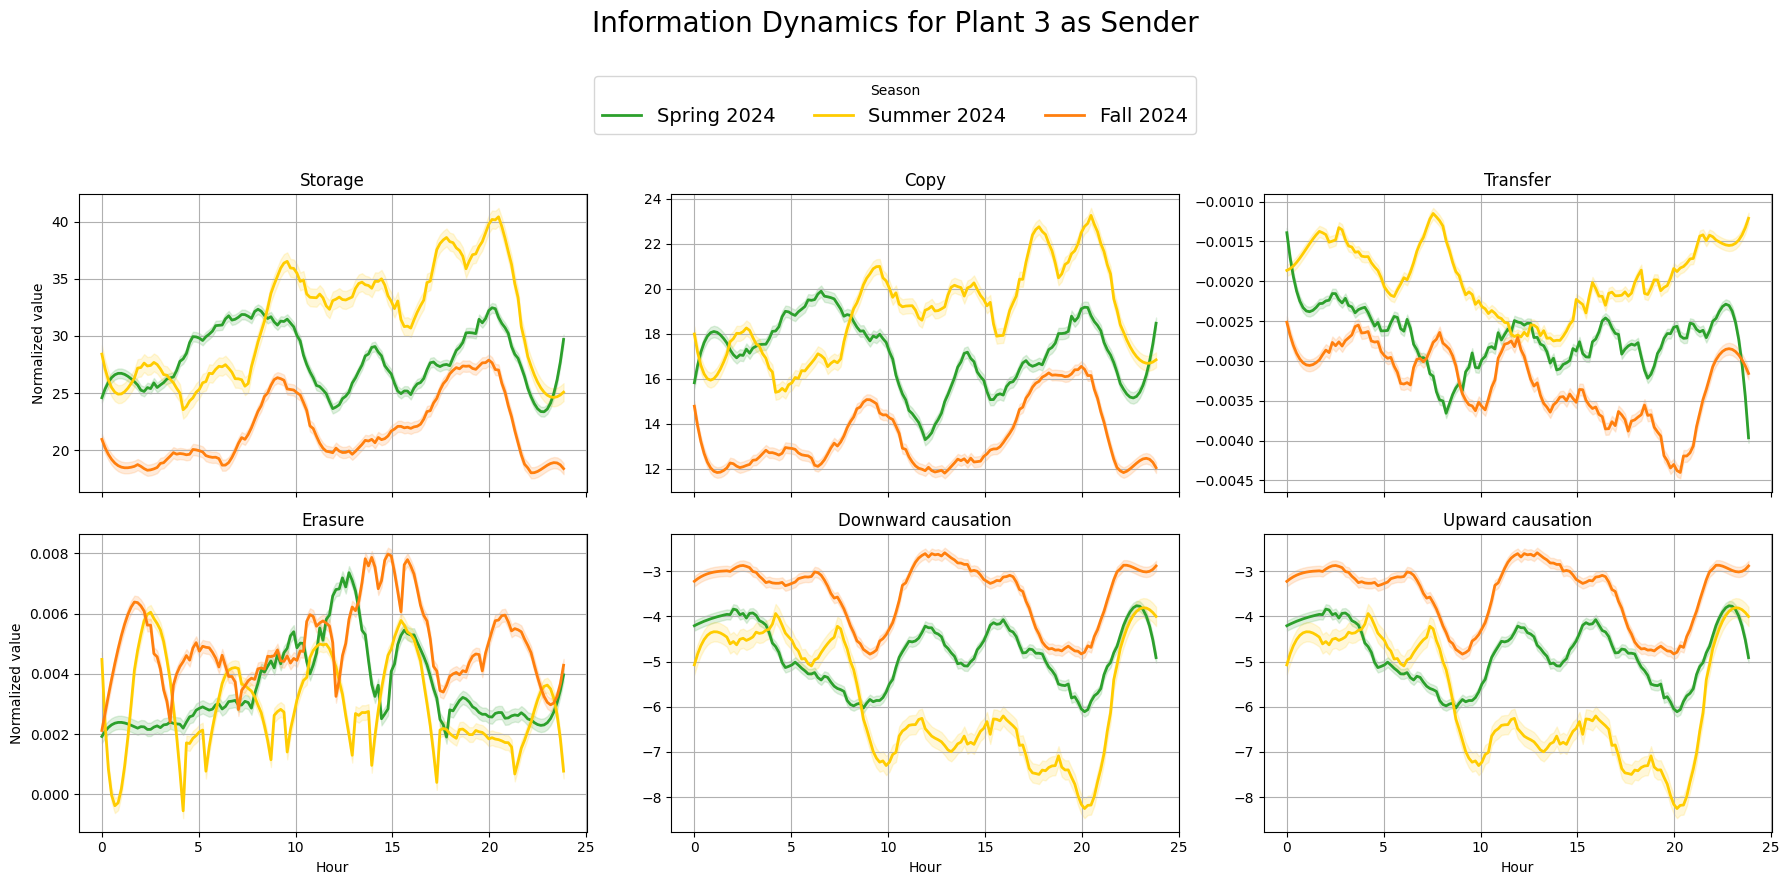

In [49]:
# ---- Pick the plant as sender ----
plant_sender = 3  # Change this to the plant you want to analyze

# --- Filter for only rows where Plant1 == plant_sender ---
df_sender = df_metrics[df_metrics["Plant1"] == plant_sender].copy()

# Recompute N_max for the sender (number of possible receivers)
plants = np.union1d(df_sender["Plant1"].unique(), df_sender["Plant2"].unique())
N_max = len(plants) - 1  # Only the other plants are valid targets

# --- Plot ---
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)
axes = axes.flatten()

for i, metric in enumerate(metric_names):
    ax = axes[i]
    for season in season_order:
        sub = df_sender[df_sender["Season_mapped"] == season]
        # Sum across all targets (Plant2) for this sender
        sum_val   = sub.groupby("Epoch")[metric].sum()
        count_val = sub.groupby("Epoch")[metric].count()
        normalized = (sum_val / count_val) * N_max

        # Clean up NaNs, smooth only if enough points
        norm_vals = normalized.values
        mask = ~np.isnan(norm_vals)
        if mask.sum() < 7:  # Not enough points to smooth
            continue
        window = min(21, mask.sum() if mask.sum() % 2 == 1 else mask.sum()-1)
        if window < 5: window = 5
        smoothed = savgol_filter(np.nan_to_num(norm_vals), window_length=window, polyorder=3)

        ci    = 1.96 * np.std(smoothed) / np.sqrt(len(smoothed))
        lower = smoothed - ci
        upper = smoothed + ci
        hours = normalized.index / total_epochs * 24

        ax.plot(hours, smoothed,
                color=color_map[season],
                linewidth=2,
                label=season if i == 0 else None)
        ax.fill_between(hours, lower, upper,
                        color=color_map[season],
                        alpha=0.15)

    ax.set_title(metric)
    ax.grid(True)
    if i % 3 == 0:
        ax.set_ylabel("Normalized value")
    if i >= 3:
        ax.set_xlabel("Hour")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, fontsize=14, title="Season", bbox_to_anchor=(0.5, 1.03))
fig.suptitle(f"Information Dynamics for Plant {plant_sender} as Sender", fontsize=20, y=1.1)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


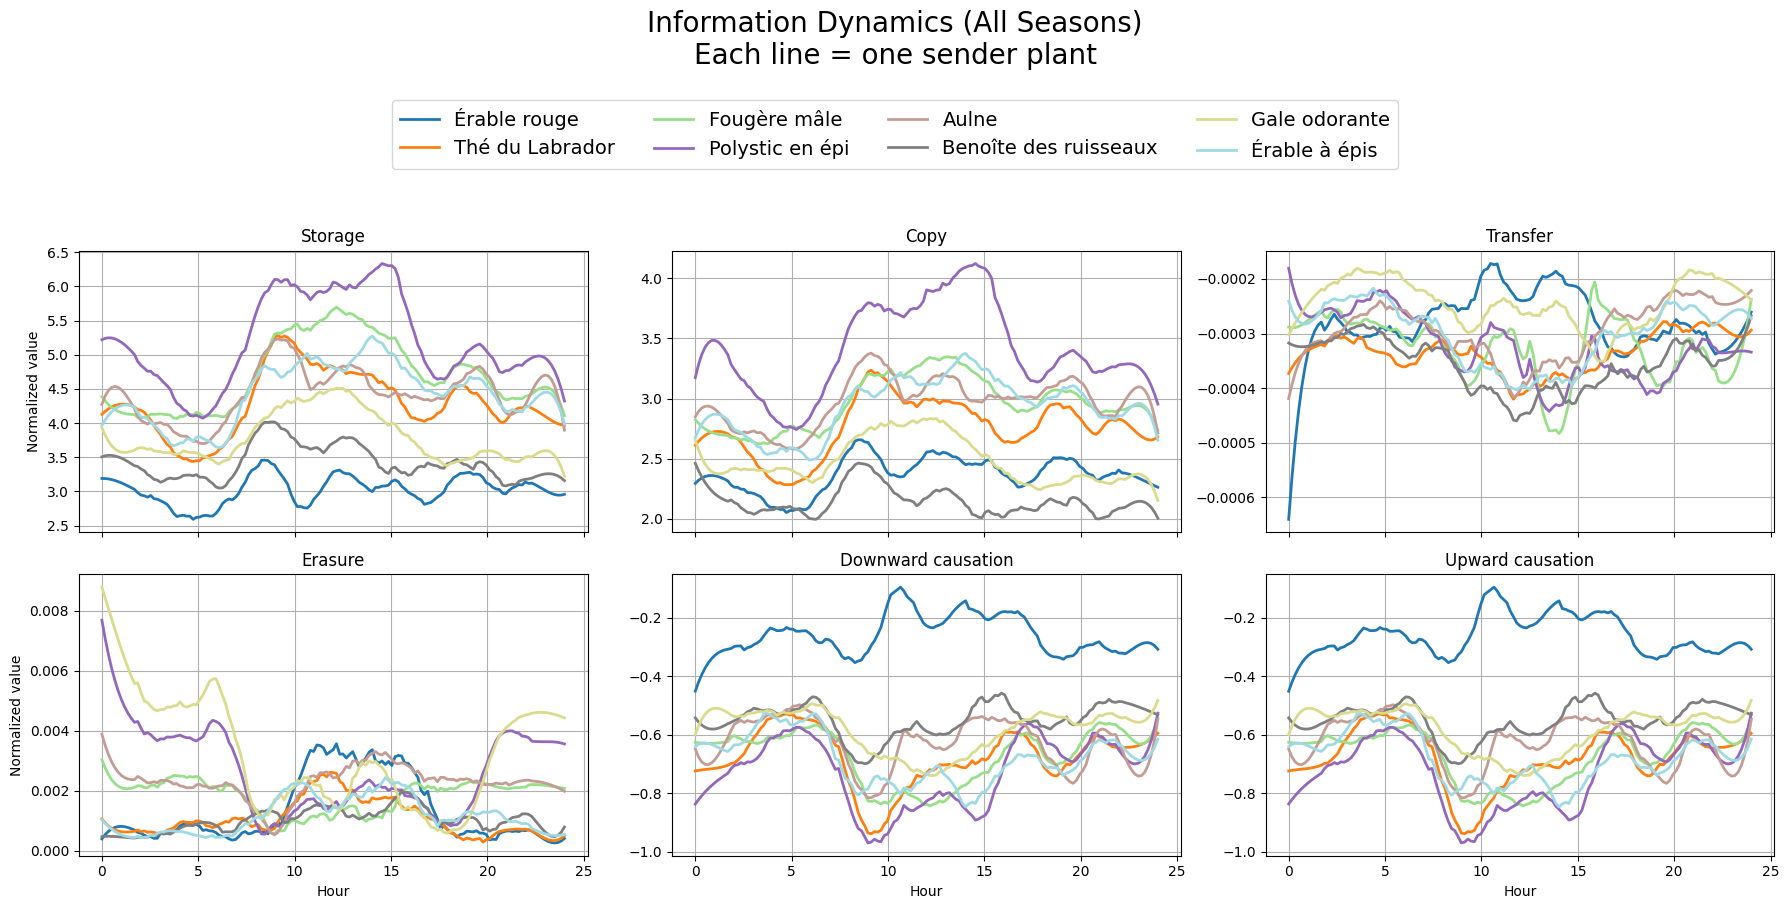

In [99]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter

# Pick which metric set you want (information_dynamics_metrics or IIT_metrics)
metric_dict = information_dynamics_metrics
metric_names = list(metric_dict.keys())

# Add the aggregate columns
df_atoms = df_all_seasons_combined
df = compute_aggregate_metrics(df_atoms, metric_dict)

plants = sorted(df["Plant1"].unique())
plant_names = {pid: name for pid, name in zip(plants, plant_common_names_fr.values())}
n_metrics = len(metric_names)
n_cols = 3
n_rows = int(np.ceil(n_metrics / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), sharex=True)
axes = axes.flatten()

colors = plt.cm.tab20(np.linspace(0, 1, len(plants)))

for i, metric in enumerate(metric_names):
    ax = axes[i]
    metric_col = metric  # assumes you have a column with this exact name; else adjust

    for j, plant_sender in enumerate(plants):
        df_sender = df[df["Plant1"] == plant_sender].copy()
        # Sum/mean over all targets for each epoch
        sum_val = df_sender.groupby("Epoch")[metric_col].sum()
        count_val = df_sender.groupby("Epoch")[metric_col].count()
        normalized = sum_val / count_val

        norm_vals = normalized.values
        mask = ~np.isnan(norm_vals)
        if mask.sum() < 7:
            continue

        window = min(21, mask.sum() if mask.sum() % 2 == 1 else mask.sum()-1)
        if window < 5: window = 5
        smoothed = savgol_filter(np.nan_to_num(norm_vals), window_length=window, polyorder=3)

        hours = normalized.index / normalized.index.max() * 24
        label = plant_names.get(plant_sender, f"Plant {plant_sender}") if i == 0 else None
        ax.plot(hours, smoothed, color=colors[j], linewidth=2, label=label)


    ax.set_title(metric)
    ax.grid(True)
    if i % n_cols == 0:
        ax.set_ylabel("Normalized value")
    if i >= n_cols * (n_rows - 1):
        ax.set_xlabel("Hour")

# Hide empty axes
for j in range(n_metrics, len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, fontsize=14, bbox_to_anchor=(0.5, 1.03))

fig.suptitle("Information Dynamics (All Seasons)\nEach line = one sender plant", fontsize=20, y=1.13)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


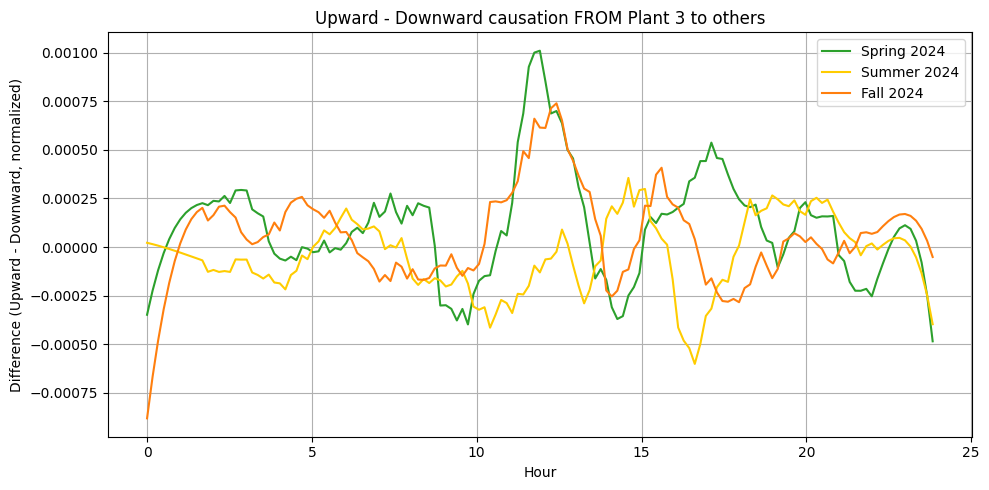

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# Choose the sender plant
target_plant = 3  # Change this to your desired sender

# Filter for this plant as sender
df_single_sender = df_metrics[df_metrics["Plant1"] == target_plant]

plt.figure(figsize=(10, 5))
for season in season_order:
    sub = df_single_sender[df_single_sender["Season_mapped"] == season]
    # Group by Epoch and aggregate
    sum_up   = sub.groupby("Epoch")["Upward causation"].sum()
    count_up = sub.groupby("Epoch")["Upward causation"].count()
    norm_up  = sum_up / count_up * (len(plants)-1)

    sum_down   = sub.groupby("Epoch")["Downward causation"].sum()
    count_down = sub.groupby("Epoch")["Downward causation"].count()
    norm_down  = sum_down / count_down * (len(plants)-1)
    
    # Align indexes
    norm_up, norm_down = norm_up.align(norm_down, join='outer')
    diff = norm_up - norm_down

    # Handle NaNs
    diff_vals = diff.values
    mask = ~np.isnan(diff_vals)
    if mask.sum() < 7:
        continue
    window = min(21, mask.sum() if mask.sum() % 2 == 1 else mask.sum()-1)
    if window < 5: window = 5
    smoothed = savgol_filter(np.nan_to_num(diff_vals), window_length=window, polyorder=3)
    hours = diff.index / total_epochs * 24

    plt.plot(hours, smoothed, color=color_map[season], label=season)

plt.title(f"Upward - Downward causation FROM Plant {target_plant} to others")
plt.xlabel("Hour")
plt.ylabel("Difference (Upward - Downward, normalized)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


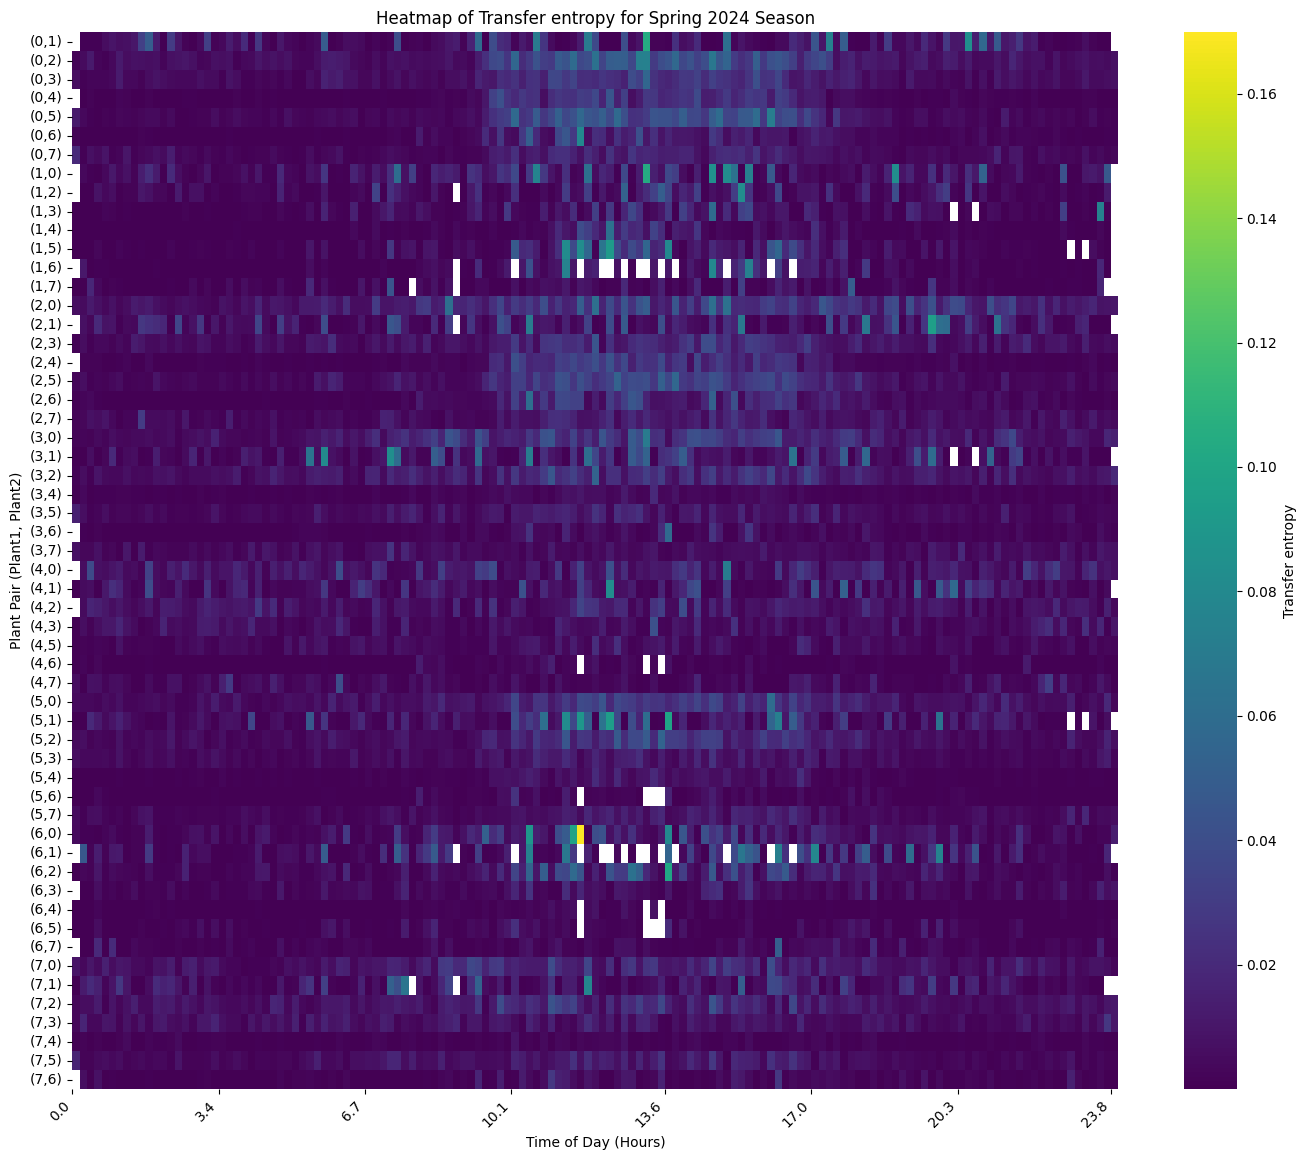

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Compute aggregate metrics (adds columns if needed)
df_metrics = compute_aggregate_metrics(df_all_seasons_combined, IIT_metrics)  # or information_dynamics_metrics

# --- Filter and prepare data ---
season = SPRING
value_col = "Transfer entropy"  # Any metric or atom name present in df_metrics

df_avg = df_metrics.groupby(
    ["Epoch", "Plant1", "Plant2", "Season"]
)[value_col].mean().reset_index()
df_plot = df_avg[df_avg['Season'] == season].copy()

# ...rest of the heatmap code from previous answer...


# Total epochs (assume 0-indexed)
total_epochs = df_plot["Epoch"].max() + 1
df_plot["Hour"] = df_plot["Epoch"] / total_epochs * 24

# Create a unique index for each plant pair as a string
df_plot["PlantPair"] = df_plot.apply(lambda row: f"({row['Plant1']},{row['Plant2']})", axis=1)

# Pivot for heatmap (rows: plant pairs, columns: hour bins)
pivot_table = df_plot.pivot(index="PlantPair", columns="Hour", values=value_col)

# Optional: restrict hours to integer bins if too dense
# pivot_table.columns = np.round(pivot_table.columns, 1)

# Define color scale (auto if many NaNs; min=nanmin, max=nanmax)
vmin = np.nanmin(pivot_table.values)
vmax = np.nanmax(pivot_table.values)

plt.figure(figsize=(14, min(0.5 + 0.20 * len(pivot_table), 12)))  # Dynamic y size for many pairs
ax = sns.heatmap(
    pivot_table,
    cmap="viridis",
    annot=False,
    linewidths=0,
    vmin=vmin,
    vmax=vmax,
    cbar_kws={"label": value_col}
)

plt.xlabel("Time of Day (Hours)")
plt.ylabel("Plant Pair (Plant1, Plant2)")
plt.title(f"Heatmap of {value_col} for {seasons[season]} Season")

# Format x-axis ticks
num_ticks = 8
hour_cols = np.array(pivot_table.columns)
tick_idx = np.linspace(0, len(hour_cols) - 1, num_ticks).astype(int)
time_labels = [f"{hour_cols[i]:.1f}" for i in tick_idx]
ax.set_xticks(tick_idx)
ax.set_xticklabels(time_labels, rotation=45, ha="right")

plt.tight_layout()
plt.show()


## All seasons

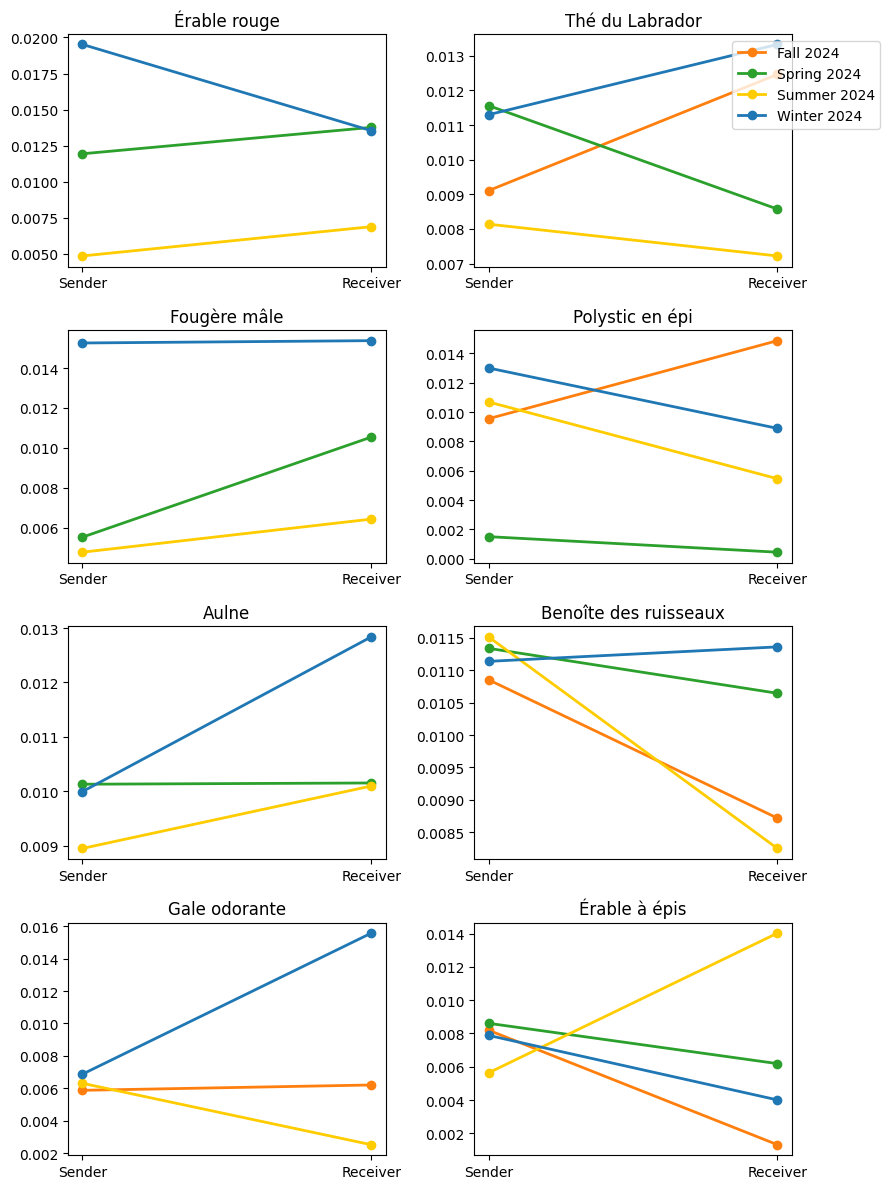

In [74]:
import matplotlib.pyplot as plt
import numpy as np

metric_dict = IIT_metrics
df_metrics = compute_aggregate_metrics(df_atoms, metric_dict)

metric = 'Transfer entropy'
# Cell: Small-multiple slopegraphs of Sender vs Receiver using 'season_colors'
if 'df_all_seasons_combined' not in globals():
    print("Please define df_all_seasons_combined, season_mapping, plant_names, metric, and season_colors before running this cell.")
else:
    # Ensure Season_mapped exists
    if 'Season_mapped' not in df_metrics:
        df_metrics['Season_mapped'] = df_all_seasons_combined['Season'].map(seasons)

    # Compute sender and receiver averages
    sender_avg = (
        df_metrics
        .groupby(['Plant1', 'Season_mapped'])[metric]
        .mean()
        .reset_index()
        .rename(columns={'Plant1': 'Plant', metric: 'sender_avg', 'Season_mapped': 'Season'})
    )
    receiver_avg = (
        df_metrics
        .groupby(['Plant2', 'Season_mapped'])[metric]
        .mean()
        .reset_index()
        .rename(columns={'Plant2': 'Plant', metric: 'receiver_avg', 'Season_mapped': 'Season'})
    )

    # Merge into single DataFrame
    avg_df = pd.merge(sender_avg, receiver_avg, on=['Plant', 'Season'], how='inner')

    # Unique plants and seasons
    plants = sorted(avg_df['Plant'].unique())
    seasons = sorted(avg_df['Season'].unique())

    # Subplot grid
    n_cols = 2
    n_rows = (len(plants) + 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(9, n_rows * 3))
    axes = axes.flatten()

    for idx, plant in enumerate(plants):
        ax = axes[idx]
        sub = avg_df[avg_df['Plant'] == plant]
        for season in seasons:
            row = sub[sub['Season'] == season]
            if row.empty:
                continue
            s = row['sender_avg'].values[0]
            r = row['receiver_avg'].values[0]
            color = season_colors.get(season, 'gray')
            ax.plot([0, 1], [s, r],
                    marker='o',
                    color=color,
                    linewidth=2,
                    label=season)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Sender', 'Receiver'])
        ax.set_title(plant_names.get(plant, plant))
        if idx == 1:
            ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1))

    # Remove any empty subplots
    for j in range(len(plants), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


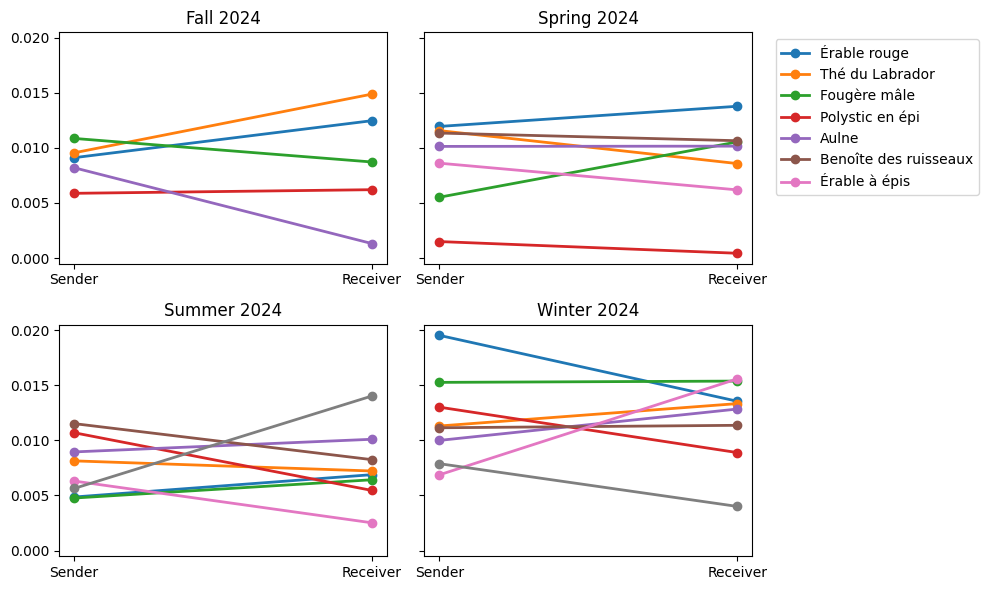

In [81]:
import matplotlib.pyplot as plt
import numpy as np

metric = 'Transfer entropy'
# Ensure Season_mapped exists
df = df_metrics.copy()
if 'Season_mapped' not in df.columns:
    df['Season_mapped'] = df['Season'].map(seasons)

# Compute sender and receiver averages per plant per season
sender_avg = (
    df.groupby(['Plant1', 'Season_mapped'])[metric]
      .mean()
      .reset_index()
      .rename(columns={'Plant1': 'Plant', metric: 'sender_avg', 'Season_mapped': 'Season'})
)
receiver_avg = (
    df.groupby(['Plant2', 'Season_mapped'])[metric]
      .mean()
      .reset_index()
      .rename(columns={'Plant2': 'Plant', metric: 'receiver_avg', 'Season_mapped': 'Season'})
)

# Merge into single DataFrame
avg_df = pd.merge(sender_avg, receiver_avg, on=['Plant', 'Season'], how='inner')

# Unique seasons and plants
seasons = sorted(avg_df['Season'].unique())
plants = sorted(avg_df['Plant'].unique())

# Plot one subplot per season
n_cols = 2
n_rows = (len(seasons) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, n_rows * 3), sharey=True)
axes = axes.flatten()

for idx, season in enumerate(seasons):
    ax = axes[idx]
    sub = avg_df[avg_df['Season'] == season]

    for plant in plants:
        row = sub[sub['Plant'] == plant]
        if row.empty:
            continue
        s = row['sender_avg'].values[0]
        r = row['receiver_avg'].values[0]
        ax.plot([0, 1], [s, r],
                marker='o',
                linewidth=2,
                label=plant_names.get(plant, plant))

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Sender', 'Receiver'])
    ax.set_title(season)
    if idx == 1:
        ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

# Remove any empty subplots
for j in range(len(seasons), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


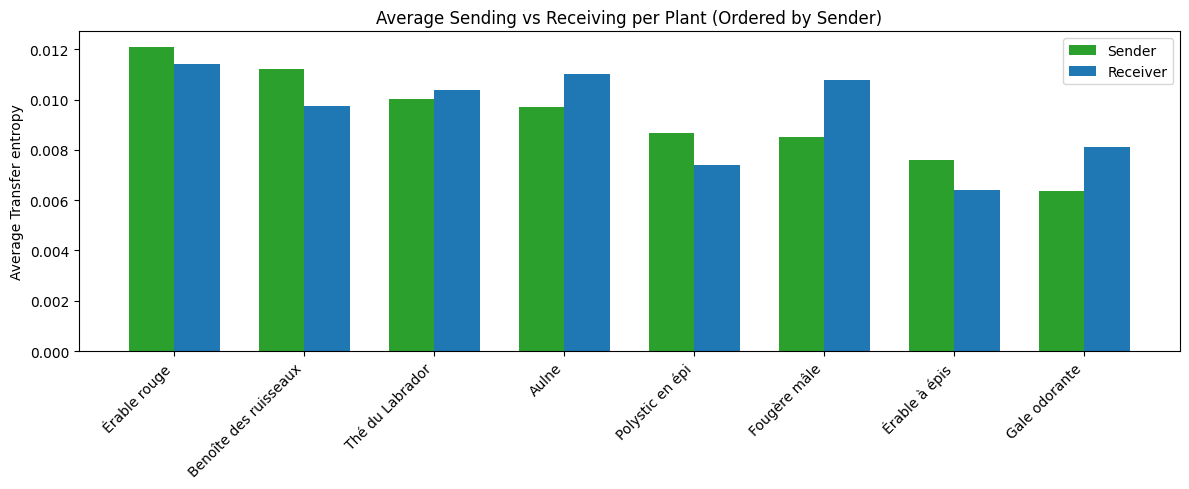

In [84]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure Season_mapped exists
if 'Season_mapped' not in df_metrics:
    df_metrics['Season_mapped'] = df_metrics['Season'].map(seasons)

# 1) Compute per-plant, per-season sender means
sender_df = (
    df_metrics
    .groupby(['Plant1', 'Season_mapped'])[metric]
    .mean()
    .reset_index()
    .rename(columns={'Plant1': 'Plant', metric: 'sender_avg'})
)

# 2) Compute per-plant, per-season receiver means
receiver_df = (
    df_metrics
    .groupby(['Plant2', 'Season_mapped'])[metric]
    .mean()
    .reset_index()
    .rename(columns={'Plant2': 'Plant', metric: 'receiver_avg'})
)

# 3) Average across seasons for each plant
sender_mean = sender_df.groupby('Plant')['sender_avg'].mean()
receiver_mean = receiver_df.groupby('Plant')['receiver_avg'].mean()

# 4) Order plants by descending sender mean
ordered_plants = sender_mean.sort_values(ascending=False).index.tolist()

# 5) Prepare x positions
x = np.arange(len(ordered_plants))
width = 0.35

# 6) Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2,
       [sender_mean[p] for p in ordered_plants],
       width, label='Sender', color='#2ca02c')
ax.bar(x + width/2,
       [receiver_mean.get(p, np.nan) for p in ordered_plants],
       width, label='Receiver', color='#1f77b4')

# 7) Formatting
ax.set_xticks(x)
ax.set_xticklabels([plant_names.get(p, p) for p in ordered_plants], rotation=45, ha='right')
ax.set_ylabel(f'Average {metric}')
ax.set_title('Average Sending vs Receiving per Plant (Ordered by Sender)')
#ax.set_ylim(0.03, 0.07)
ax.legend()
plt.tight_layout()
plt.show()


{7: 9.45059729762523e-65, 1: 2.3440073383458396e-52, 5: 0.03412895899496009, 4: 2.5920569314770867e-07, 2: 3.238115683859733e-37, 3: 0.05661044738673382, 6: 2.5920569314770867e-07, 0: 2.896666732246824e-65}


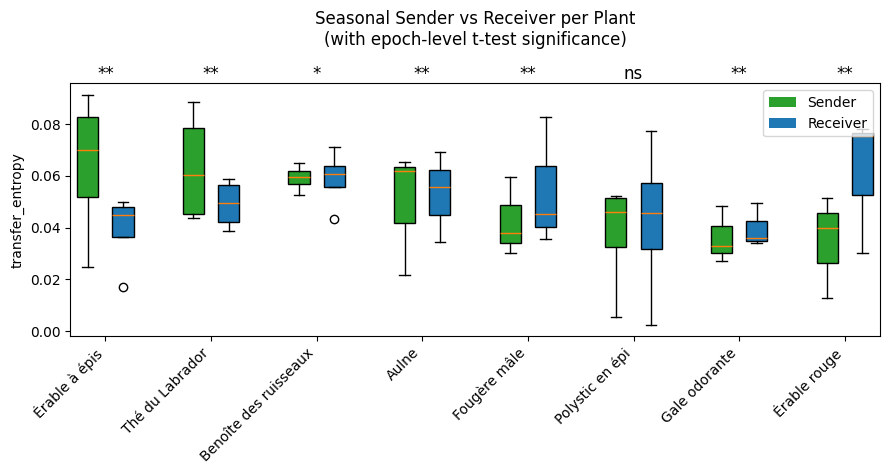

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
from matplotlib.patches import Patch

# Copy DataFrame and ensure Season_mapped exists
df = df_all_seasons_combined.copy()
if 'Season_mapped' not in df.columns:
    df['Season_mapped'] = df['Season'].map(seasons)

# 1) Compute per-plant, per-epoch values for sender and receiver
sender_epoch = (
    df.groupby(['Plant1', 'Epoch'])[metric]
      .mean()
      .reset_index()
      .rename(columns={'Plant1':'Plant', metric:'sender'})
)
receiver_epoch = (
    df.groupby(['Plant2', 'Epoch'])[metric]
      .mean()
      .reset_index()
      .rename(columns={'Plant2':'Plant', metric:'receiver'})
)

# Merge sender & receiver so they align by Plant & Epoch
paired_epoch = pd.merge(sender_epoch, receiver_epoch, on=['Plant','Epoch'], how='inner')

# 2) Compute per-plant, per-season means for the boxplot
sender_df = (
    df.groupby(['Plant1', 'Season_mapped'])[metric]
      .mean()
      .reset_index()
      .rename(columns={'Plant1':'Plant', metric:'Value'})
)
sender_df['Type'] = 'Sender'
receiver_df = (
    df.groupby(['Plant2', 'Season_mapped'])[metric]
      .mean()
      .reset_index()
      .rename(columns={'Plant2':'Plant', metric:'Value'})
)
receiver_df['Type'] = 'Receiver'
combined = pd.concat([sender_df, receiver_df], ignore_index=True)

# 3) Determine ordering by descending mean sender (seasonal)
order = sender_df.groupby('Plant')['Value'].mean().sort_values(ascending=False).index.tolist()

# 4) Run paired t-test per plant using all epochs
p_values = {}
for plant in order:
    s_vals = paired_epoch[paired_epoch['Plant']==plant]['sender']
    r_vals = paired_epoch[paired_epoch['Plant']==plant]['receiver']
    if len(s_vals) >= 2 and len(r_vals) >= 2:
        _, p = ttest_rel(s_vals, r_vals)
    else:
        p = np.nan
    p_values[plant] = p

# 5) Prepare data and positions for boxplot (seasonal distribution)
data = []
positions = []
colors = []
for i, plant in enumerate(order):
    for typ, color in [('Sender', '#2ca02c'), ('Receiver', '#1f77b4')]:
        vals = combined[(combined['Plant']==plant) & (combined['Type']==typ)]['Value'].values
        data.append(vals)
        positions.append(i*3 + (0 if typ=='Sender' else 1))
        colors.append(color)

# 6) Create boxplot
fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(data, positions=positions, widths=0.6, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# 7) Configure x-axis labels
ax.set_xticks([i*3 + 0.5 for i in range(len(order))])
ax.set_xticklabels([plant_names.get(p, p) for p in order], rotation=45, ha='right')

# 8) Add legend
legend_handles = [Patch(facecolor='#2ca02c', label='Sender'),
                  Patch(facecolor='#1f77b4', label='Receiver')]
ax.legend(handles=legend_handles, loc='upper right')

# 9) Add significance stars based on epoch t-test
max_vals = [np.nanmax(arr) for arr in data if len(arr)>0]
y_max    = max(max_vals) * 1.05 if max_vals else 1

# correct the p values with FDR 

from statsmodels.stats.multitest import multipletests

_, p_values_corrected, _, _ = multipletests(list(p_values.values()), method='fdr_bh')
p_values = dict(zip(order, p_values_corrected))
print(p_values)
for i, plant in enumerate(order):
    p = p_values.get(plant, np.nan)
    if np.isnan(p):
        star = ''
    elif p <= 0.01:
        star = '**'
    elif p <= 0.05:
        star = '*'
    else:
        star = 'ns'
    ax.text(i*3 + 0.5, y_max, star, ha='center', va='bottom', fontsize=12)

# 9) Labels and title
ax.set_ylabel(metric)
ax.set_title('Seasonal Sender vs Receiver per Plant\n(with epoch-level t-test significance)',  y=1.12)
# move the supertitle up
plt.tight_layout()
plt.show()


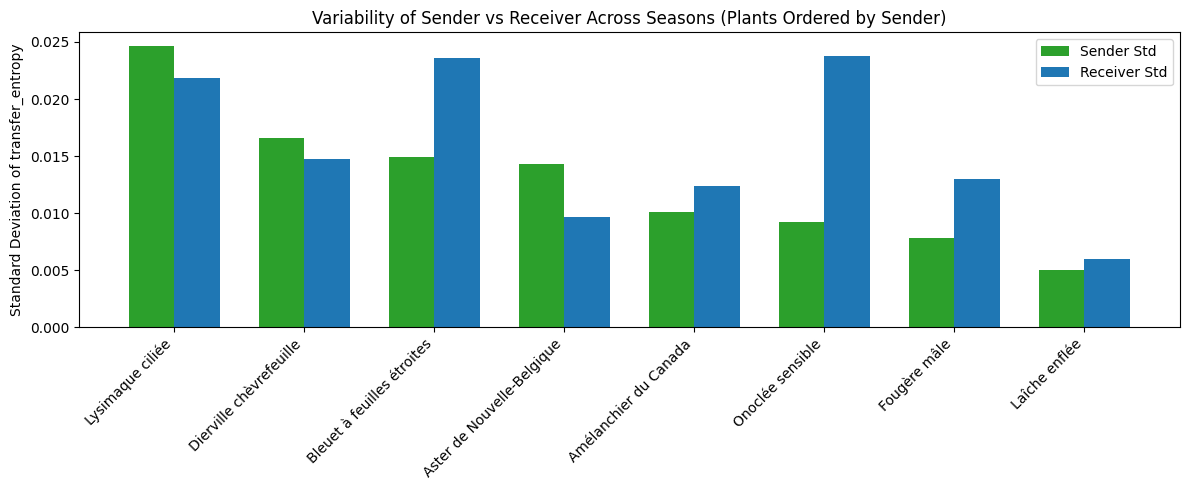

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure Season_mapped exists
if 'Season_mapped' not in df_all_seasons_combined.columns:
    df_all_seasons_combined['Season_mapped'] = df_all_seasons_combined['Season'].map(season_mapping)

# 1) Compute per-plant, per-season averages
sender_avg = (
    df_all_seasons_combined
    .groupby(['Plant1', 'Season_mapped'])[metric]
    .mean()
    .reset_index()
    .rename(columns={'Plant1': 'Plant', metric: 'sender_avg'})
)

receiver_avg = (
    df_all_seasons_combined
    .groupby(['Plant2', 'Season_mapped'])[metric]
    .mean()
    .reset_index()
    .rename(columns={'Plant2': 'Plant', metric: 'receiver_avg'})
)

# 2) Compute standard deviation across seasons for each plant
sender_var = sender_avg.groupby('Plant')['sender_avg'].std().fillna(0)
receiver_var = receiver_avg.groupby('Plant')['receiver_avg'].std().fillna(0)

# 3) Order plants by descending sender variability
ordered_plants = sender_var.sort_values(ascending=False).index.tolist()

# 4) Prepare x positions
x = np.arange(len(ordered_plants))
width = 0.35

# 5) Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2,
       [sender_var[p] for p in ordered_plants],
       width, label='Sender Std', color='#2ca02c')
ax.bar(x + width/2,
       [receiver_var.get(p, 0) for p in ordered_plants],
       width, label='Receiver Std', color='#1f77b4')

# 6) Formatting
ax.set_xticks(x)
ax.set_xticklabels([plant_names.get(p, p) for p in ordered_plants], rotation=45, ha='right')
ax.set_ylabel(f'Standard Deviation of {metric}')
ax.set_title('Variability of Sender vs Receiver Across Seasons (Plants Ordered by Sender)')
ax.legend()
plt.tight_layout()
plt.show()


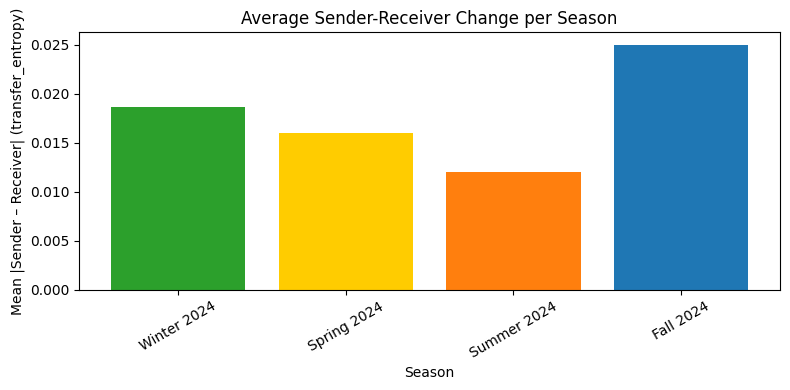

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Ensure Season_mapped exists
if 'Season_mapped' not in df_all_seasons_combined.columns:
    df_all_seasons_combined['Season_mapped'] = df_all_seasons_combined['Season'].map(season_mapping)

# 2) Compute average sender and receiver per Plant & Season
sender_avg = (
    df_all_seasons_combined
    .groupby(['Plant1', 'Season_mapped'])[metric]
    .mean()
    .reset_index()
    .rename(columns={'Plant1': 'Plant', metric: 'sender_avg', 'Season_mapped': 'Season'})
)

receiver_avg = (
    df_all_seasons_combined
    .groupby(['Plant2', 'Season_mapped'])[metric]
    .mean()
    .reset_index()
    .rename(columns={'Plant2': 'Plant', metric: 'receiver_avg', 'Season_mapped': 'Season'})
)

# 3) Merge to get a DataFrame with sender and receiver averages
avg_df = pd.merge(sender_avg, receiver_avg, on=['Plant', 'Season'], how='inner')

# 4) Compute absolute difference per Plant & Season
avg_df['abs_diff'] = np.abs(avg_df['sender_avg'] - avg_df['receiver_avg'])

# 5) Compute mean absolute difference per Season
season_diff = avg_df.groupby('Season')['abs_diff'].mean()

# 6) Order seasons chronologically
season_index = {"Winter": 0, "Spring": 1, "Summer": 2, "Fall": 3}
season_order = sorted(
    season_diff.index,
    key=lambda nm: (int(nm.split()[1]), season_index[nm.split()[0]])
)

# 7) Define your color mapping
colors = ["#2ca02c", "#ffcc00", "#ff7f0e", "#1f77b4"]  # spring, summer, fall, winter
# Align colors to season_order
# Assuming season_order is [Winter ..., Spring ..., Summer ..., Fall ...],
# we need to map each to the correct color:
color_map = {
    season: colors[idx]
    for idx, season in enumerate(season_order)
}

# 8) Plot bar chart
plt.figure(figsize=(8, 4))
values = [season_diff[s] for s in season_order]
bar_colors = [color_map[s] for s in season_order]
plt.bar(season_order, values, color=bar_colors)

plt.xlabel("Season")
plt.ylabel(f"Mean |Sender – Receiver| ({metric})")
plt.title("Average Sender-Receiver Change per Season")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [ ]:
seasons

['Fall 2024', 'Spring 2024', 'Summer 2024', 'Winter 2024']

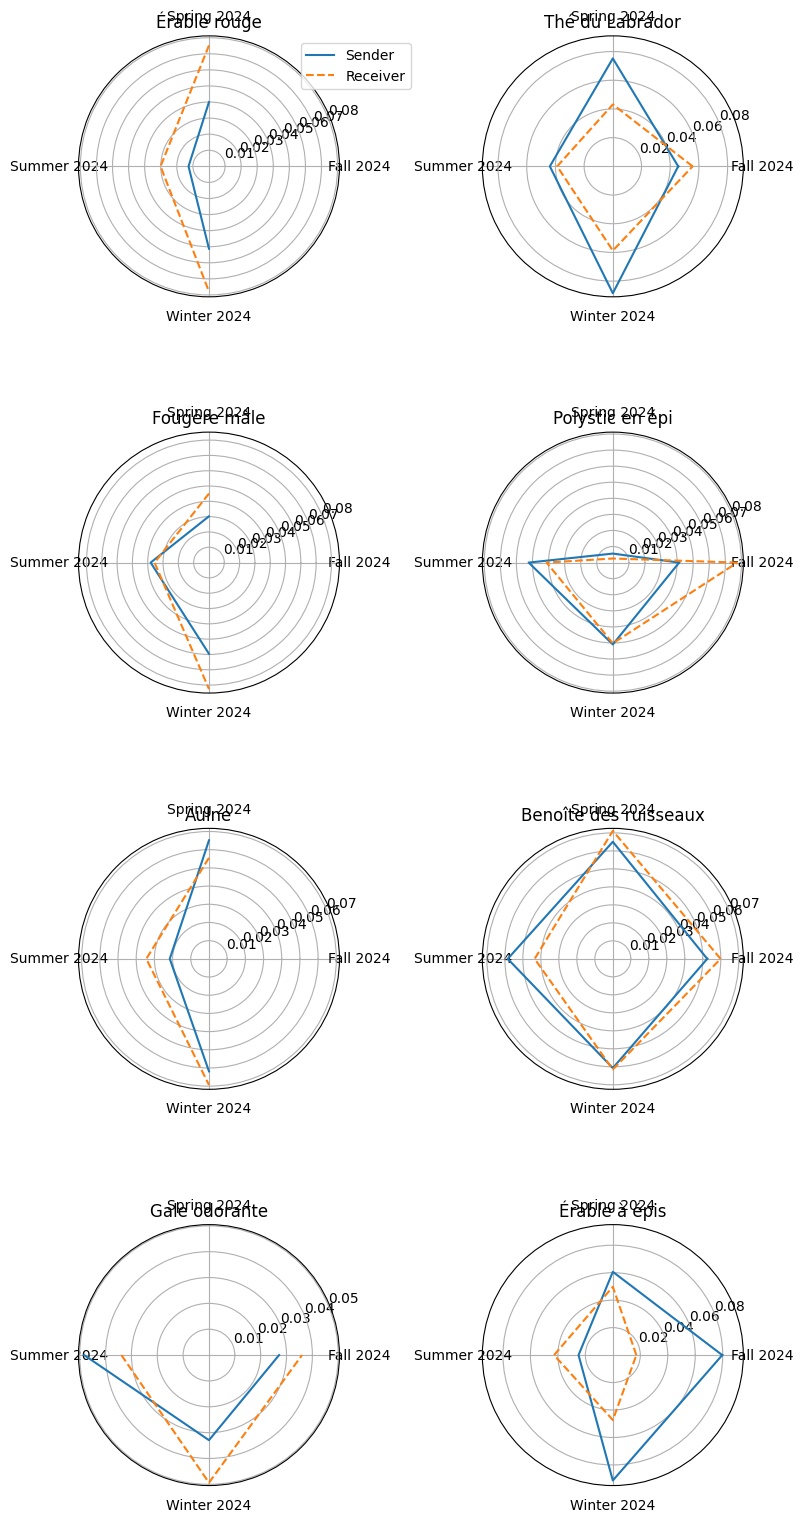

In [ ]:
# Cell 4: Radar charts of seasonal profiles (Sender vs Receiver)
if 'df_all_seasons_combined' not in globals():
    print("Please define df_all_seasons_combined, season_mapping, plant_names, and metric before running this cell.")
else:
    import numpy as np

    # Compute seasonal averages
    sender_avg = (
        df_all_seasons_combined
        .groupby(['Plant1','Season_mapped'])[metric]
        .mean()
        .rename('sender')
        .reset_index()
    )
    receiver_avg = (
        df_all_seasons_combined
        .groupby(['Plant2','Season_mapped'])[metric]
        .mean()
        .rename('receiver')
        .reset_index()
    )

    # Merge into one DataFrame
    avg_df = pd.merge(
        sender_avg, receiver_avg,
        left_on=['Plant1','Season_mapped'],
        right_on=['Plant2','Season_mapped'],
        how='outer'  # outer so we don't lose plants or seasons entirely
    ).rename(columns={'Plant1':'Plant'}).drop(columns=['Plant2'])

    # Radar chart setup
    plants   = sorted(avg_df['Plant'].dropna().unique())
    seasons_ = sorted(df_all_seasons_combined['Season_mapped'].dropna().unique())
    N        = len(seasons_)
    # angles for each season axis
    angles   = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles  += angles[:1]

    # figure with subplots in polar coordinates
    n_cols = 2
    n_rows = (len(plants) + 1) // 2
    fig    = plt.figure(figsize=(8, n_rows * 4))

    for idx, plant in enumerate(plants, start=1):
        ax = fig.add_subplot(n_rows, n_cols, idx, polar=True)

        # filter for this plant, then reindex so every season is present
        sub = avg_df[avg_df['Plant'] == plant].set_index('Season_mapped')
        sub = sub.reindex(seasons_, fill_value=np.nan)

        # extract values and close the loop
        sender_vals   = sub['sender'].tolist() + [sub['sender'].iloc[0]]
        receiver_vals = sub['receiver'].tolist() + [sub['receiver'].iloc[0]]

        # plot sender (solid) and receiver (dashed)
        ax.plot(angles, sender_vals,   linestyle='-',  label='Sender')
        ax.plot(angles, receiver_vals, linestyle='--', label='Receiver')

        # set the axis labels
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(seasons_)
        ax.set_title(plant_names.get(plant, plant))

        # only add legend on the first plot
        if idx == 1:
            ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1))

    plt.tight_layout()
    plt.show()


## Graph (to do)

In [ ]:
# recompute edge sums across all seasons, not just df_avg
full_group = (
    df_all_seasons_combined
      .groupby(["Plant1","Plant2"])[metric]
      .sum()
)
print(full_group.loc[4])   # see all outgoing from 3
print(full_group[full_group.index.get_level_values(1)==4])  # incoming


Plant2
0    34.814909
1    27.281157
2    37.770802
3    26.614669
5    20.782777
6    13.929108
7    24.482732
Name: transfer_entropy, dtype: float64
Plant1  Plant2
0       4         22.691104
1       4         20.209339
2       4         29.201855
3       4         18.689058
5       4         14.400313
6       4         11.879315
7       4         30.549020
Name: transfer_entropy, dtype: float64


## Graph with total transfer-­entropy summed over all epochs and seasons

Outgoing→Incoming TE stats (count, mean):
               count      mean
Plant1 Plant2                 
0      1         429  0.040368
       2         429  0.039975
       3         429  0.015402
       4         429  0.041433
       5         429  0.046454
       6         286  0.020403
       7         429  0.031943
1      0         429  0.091199
       2         429  0.072478
       3         572  0.047989
       4         429  0.077972
       5         572  0.073836
       6         429  0.043850
       7         572  0.053974
2      0         429  0.044491
       1         429  0.044295
       3         429  0.032509
       4         429  0.045622
       5         429  0.053188
       6         286  0.048752
       7         429  0.035769
3      0         429  0.037289
       1         572  0.040770
       2         429  0.036623
       4         429  0.035418
       5         429  0.056105
       6         429  0.037286
       7         572  0.036246
4      0         429  0.0651

C:\Users\skite\AppData\Local\Temp\ipykernel_48032\2414247965.py:84: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("coolwarm", 256)  # colormap for edges


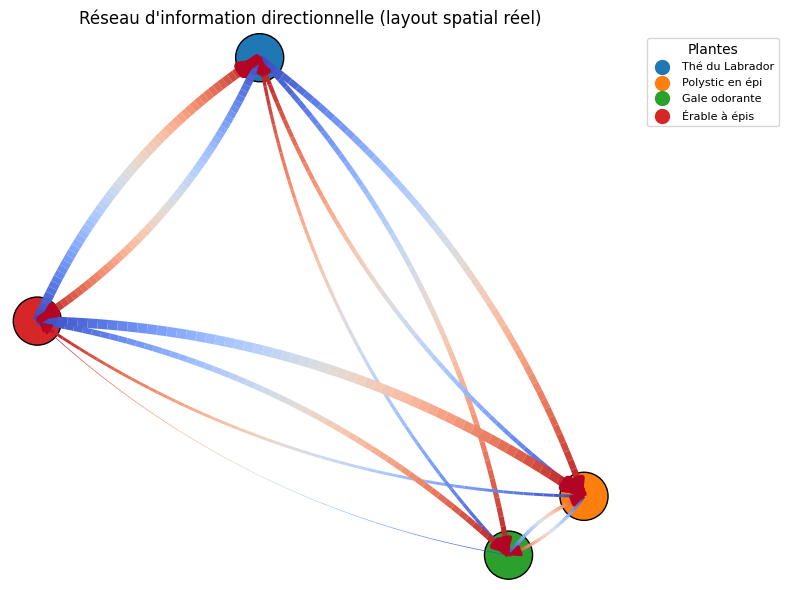

In [ ]:
import numpy as np
from sklearn.manifold import MDS
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import MDS
from matplotlib.collections import LineCollection
from matplotlib import cm
import matplotlib.lines as mlines


# 1) Extract plant IDs present in the distances dict
plant_ids = sorted({i for pair in plant_distances.keys() for i in pair})

# 2) Build the distance matrix only for those IDs
n = len(plant_ids)
dist_matrix = np.zeros((n, n))
for (i, j), d in plant_distances.items():
    if i in plant_ids and j in plant_ids:
        # map original index to position in our submatrix
        pi, pj = plant_ids.index(i), plant_ids.index(j)
        dist_matrix[pi, pj] = d
        dist_matrix[pj, pi] = d

# 3) MDS to get 2D spatial coordinates
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
coords = mds.fit_transform(dist_matrix)

# 4) Map each plant ID to its 2D position
plant_positions = {pid: tuple(coords[idx]) for idx, pid in enumerate(plant_ids)}

# 5) Build directed graph using only those IDs
edge_stats = (
    df_all_seasons_combined
      .groupby(['Plant1','Plant2'])[metric]
      .agg(count='count', mean='mean')
)

# Show the table so you can check missingness
print("Outgoing→Incoming TE stats (count, mean):")
print(edge_stats)

# Now build G using only pairs with count>0
G = nx.DiGraph()
for (p1, p2), stats in edge_stats.iterrows():
    cnt, avg_te = stats['count'], stats['mean']
    if p1 in plant_ids and p2 in plant_ids and cnt > 0:
        G.add_edge(p1, p2, weight=avg_te)

# Proceed with your linewidth scaling…
raw_weights = np.array([d["weight"] for _, _, d in G.edges(data=True)])
w_min, w_max = raw_weights.min(), raw_weights.max()
lw_min, lw_max = 0.5, 7.0

fig, ax = plt.subplots(figsize=(8, 6))

# 1) Choose a qualitative colormap and assign one color per plant
cmap = plt.get_cmap("tab10")   # good for up to 10 distinct categories
plant_colors = {pid: cmap(i) for i, pid in enumerate(plant_ids)}

# 2) Draw nodes with those colors
# 2) Draw **all** plants as nodes (including those with no edges)
nx.draw_networkx_nodes(
    G,
    plant_positions,
    nodelist=plant_ids,                                # include every plant
    node_color=[plant_colors[pid] for pid in plant_ids],
    edgecolors="black",
    node_size=1200,
    ax=ax
)

# 3) Draw labels with names
labels = {pid: plant_names.get(pid, str(pid)) for pid in G.nodes()}
# nx.draw_networkx_labels(
#     G,
#     plant_positions,
#     labels=labels,
#     font_size=10,
#     font_weight="bold",
#     ax=ax
# )

cmap = cm.get_cmap("coolwarm", 256)  # colormap for edges
rad = 0.15

for u, v, d in G.edges(data=True):
    # endpoints
    x1, y1 = plant_positions[u]
    x2, y2 = plant_positions[v]
    raw = d["weight"]
    # normalize and map to linewidth
    t = (raw - w_min) / (w_max - w_min) if w_max > w_min else 0.5
    w = lw_min + t * (lw_max - lw_min)

    # Bézier control point for arc
    dx, dy = x2 - x1, y2 - y1
    length = np.hypot(dx, dy)
    perp = np.array([-dy, dx]) / length if length else np.array([0, 0])
    mx, my = (x1 + x2) / 2, (y1 + y2) / 2
    cx, cy = mx + perp[0] * rad * length, my + perp[1] * rad * length

    # sample curve
    N = 60
    tvals = np.linspace(0, 1, N)
    xs = (1 - tvals)**2 * x1 + 2 * (1 - tvals) * tvals * cx + tvals**2 * x2
    ys = (1 - tvals)**2 * y1 + 2 * (1 - tvals) * tvals * cy + tvals**2 * y2

    # build segments & draw with gradient
    points = np.vstack([xs, ys]).T.reshape(-1, 1, 2)
    segs = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segs, linewidths=w, cmap=cmap,
                        norm=plt.Normalize(0, 1))
    lc.set_array(np.linspace(0, 1, len(segs)))
    ax.add_collection(lc)

    # arrowhead colored at 100% of the colormap
    arrow_color = cmap(1.0)
    ax.annotate(
        "",
        xy=(xs[-1], ys[-1]), xytext=(xs[-2], ys[-2]),
        arrowprops=dict(arrowstyle="-|>", color=arrow_color, lw=w),
        size=15
    )

# edge labels (optional)
edge_labels = {(i, j): f"{d['weight']:.2f}" for i, j, d in G.edges(data=True)}
# nx.draw_networkx_edge_labels(G, plant_positions, edge_labels=edge_labels,
#                              font_size=0, label_pos=0.3, ax=ax)

# legend with plant names
handles = [
    mlines.Line2D(
        [], [], 
        color=plant_colors[pid], 
        marker='o', 
        linestyle='None',
        markersize=10,
        label=plant_names.get(pid, str(pid))
    )
    for pid in plant_ids
]
ax.legend(
    handles=handles,
    title="Plantes",
    loc='upper left',
    bbox_to_anchor=(1.05, 1),
    fontsize=8,
    title_fontsize=10
)

ax.set_title("Réseau d'information directionnelle (layout spatial réel)")
ax.axis('off')
plt.tight_layout()
plt.show()



## Graph with seasonal average

C:\Users\skite\AppData\Local\Temp\ipykernel_48032\114347560.py:75: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_edges = cm.get_cmap("Blues")


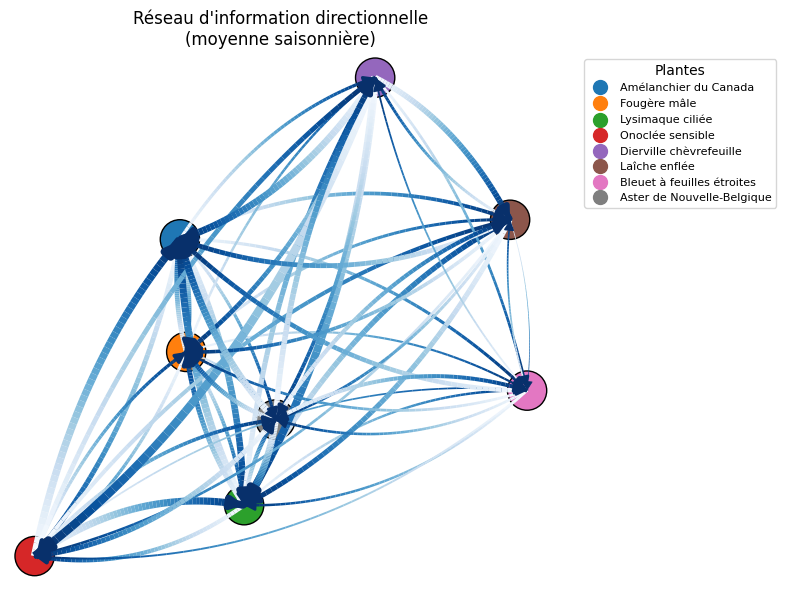

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
from matplotlib.collections import LineCollection
from matplotlib import cm
import matplotlib.lines as mlines

# --- 0) prep a numeric→species→French map ---
species_list = list(plant_common_names_fr.keys())
plant_french = plant_common_names_fr  # species_str → French

# --- 1) seasonal sums → mean TE per edge ---
edge_seasonal = (
    df_all_seasons_combined
      .groupby(['Plant1','Plant2','Season_mapped'])[metric]
      .sum()
      .reset_index(name='seasonal_sum')
)
edge_mean = (
    edge_seasonal
      .groupby(['Plant1','Plant2'])['seasonal_sum']
      .mean()
      .to_dict()
)

# --- 2) get only the numeric IDs that actually have distances ---
plant_ids = sorted({i for (i,j) in plant_distances.keys()} |
                   {j for (i,j) in plant_distances.keys()})

# --- 3) build G only for those valid IDs ---
G = nx.DiGraph()
for (i_idx, j_idx), w in edge_mean.items():
    if w > 0 and i_idx in plant_ids and j_idx in plant_ids:
        u = species_list[i_idx]   # species string
        v = species_list[j_idx]
        G.add_edge(u, v, weight=w)

# --- 4) compute MDS on your numeric distances ---
n = len(plant_ids)
D = np.zeros((n,n))
for (i,j), dist in plant_distances.items():
    pi, pj = plant_ids.index(i), plant_ids.index(j)
    D[pi,pj] = D[pj,pi] = dist
coords = MDS(n_components=2, dissimilarity='precomputed', random_state=42) \
         .fit_transform(D)

# map species → position (only for valid IDs)
pos = {
    species_list[k]: tuple(coords[plant_ids.index(k)]) 
    for k in plant_ids
}

# drop any nodes that slipped in without a position
G = G.subgraph(pos.keys()).copy()

# --- 5) prepare linewidth scaling ---
ws = np.array([d['weight'] for _,_,d in G.edges(data=True)])
w_min, w_max = ws.min(), ws.max()
lw_min, lw_max = 0.5, 6.0

# --- 6) draw everything ---
fig, ax = plt.subplots(figsize=(8,6))

# node colors by species
cmap_nodes = plt.get_cmap("tab10")
species_colors = {sp: cmap_nodes(i) for i, sp in enumerate(pos.keys())}
nx.draw_networkx_nodes(
    G, pos,
    node_color=[species_colors[sp] for sp in G.nodes()],
    edgecolors="black", node_size=800, ax=ax
)

# gradient, curved edges
cmap_edges = cm.get_cmap("Blues")
rad = 0.15
for u, v, d in G.edges(data=True):
    x1, y1 = pos[u]; x2, y2 = pos[v]
    norm = (d['weight'] - w_min)/(w_max - w_min) if w_max> w_min else 0.5
    w = lw_min + norm*(lw_max - lw_min)

    dx, dy = x2-x1, y2-y1
    length = np.hypot(dx, dy)
    perp = np.array([-dy, dx]) / length if length else np.array([0,0])
    mx, my = (x1+x2)/2, (y1+y2)/2
    cx, cy = mx + perp[0]*rad*length, my + perp[1]*rad*length

    N = 60
    t = np.linspace(0,1,N)
    xs = (1-t)**2*x1 + 2*(1-t)*t*cx + t**2*x2
    ys = (1-t)**2*y1 + 2*(1-t)*t*cy + t**2*y2
    pts = np.vstack([xs, ys]).T.reshape(-1,1,2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)

    lc = LineCollection(segs, linewidths=w, cmap=cmap_edges,
                        norm=plt.Normalize(0,1))
    lc.set_array(np.linspace(0,1,len(segs)))
    ax.add_collection(lc)

    arrow_col = cmap_edges(1.0)
    ax.annotate("", xy=(xs[-1], ys[-1]), xytext=(xs[-2], ys[-2]),
                arrowprops=dict(arrowstyle='-|>', 
                                color=arrow_col, lw=w),
                size=15)

# legend of nodes (only those drawn)
handles = [
    mlines.Line2D([], [], marker='o', linestyle='None',
                  markersize=10, color=species_colors[sp],
                  label=plant_french[sp])
    for sp in pos.keys()
]
ax.legend(handles=handles, title="Plantes",
          loc='upper left', bbox_to_anchor=(1.05,1),
          fontsize=8, title_fontsize=10)

ax.set_title("Réseau d'information directionnelle\n(moyenne saisonnière)")
ax.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# ─── Autonomous Consistency Check ───

import numpy as np
import networkx as nx

# 1) Build an ordered species list and integer→French-name mapping
species_list = list(plant_common_names_fr.keys())
plant_names = {i: plant_common_names_fr[species_list[i]] for i in range(len(species_list))}

# 2) Extract all integer IDs from your distance dict
plant_ids = sorted({x for pair in plant_distances.keys() for x in pair})

# 3) Check that every ID has a French common name
missing = set(plant_ids) - set(plant_names.keys())
assert not missing, f"❌ Missing IDs in plant_names: {missing!r}"

# 4) Validate each entry in plant_distances → correct label lookup
print("plant_distances entries with labels:")
for (i, j), dist in plant_distances.items():
    name_i = plant_names[i]
    name_j = plant_names[j]
    print(f"  {i} → {j} : {name_i} → {name_j}   (distance = {dist:.3f})")

# 5) Build directed graph G from df_avg sums
G = nx.DiGraph()
grouped = df_avg.groupby(['Plant1','Plant2'])[metric].sum().to_dict()
for (p1, p2), w in grouped.items():
    if w > 0:
        G.add_edge(p1, p2, weight=w)

# 6) Validate G edges match df_avg sums and label lookup
print("\nG edges with weights and labels:")
for u, v, d in G.edges(data=True):
    expected = grouped[(u, v)]
    actual   = d['weight']
    assert abs(actual - expected) < 1e-6, \
        f"❌ Weight mismatch for edge {u}->{v}: graph has {actual}, df_avg sums to {expected}"
    print(f"  {u}->{v} : {plant_names[u]} → {plant_names[v]}   (weight = {actual:.3f})")

# 7) Check monotonicity of weights → arrow thickness mapping
weights = np.array([d['weight'] for _,_,d in G.edges(data=True)])
if len(weights) > 1:
    diffs = np.diff(np.sort(weights))
    assert np.all(diffs >= 0), "❌ Transfer-entropy weights are not non-decreasing"

print("\n✅ All consistency checks passed: IDs, labels, edge weights, and ordering are correct.")


plant_distances entries with labels:
  0 → 1 : Amélanchier du Canada → Fougère mâle   (distance = 40.000)
  0 → 2 : Amélanchier du Canada → Lysimaque ciliée   (distance = 99.819)
  0 → 3 : Amélanchier du Canada → Onoclée sensible   (distance = 135.341)
  0 → 4 : Amélanchier du Canada → Dierville chèvrefeuille   (distance = 114.927)
  0 → 5 : Amélanchier du Canada → Laîche enflée   (distance = 168.411)
  0 → 6 : Amélanchier du Canada → Bleuet à feuilles étroites   (distance = 184.897)
  0 → 7 : Amélanchier du Canada → Aster de Nouvelle-Belgique   (distance = 80.211)
  1 → 2 : Fougère mâle → Lysimaque ciliée   (distance = 61.954)
  1 → 3 : Fougère mâle → Onoclée sensible   (distance = 106.234)
  1 → 4 : Fougère mâle → Dierville chèvrefeuille   (distance = 136.881)
  1 → 5 : Fougère mâle → Laîche enflée   (distance = 171.512)
  1 → 6 : Fougère mâle → Bleuet à feuilles étroites   (distance = 174.213)
  1 → 7 : Fougère mâle → Aster de Nouvelle-Belgique   (distance = 51.379)
  2 → 3 : Lysima

In [ ]:
plant_common_names_fr

{'Amelanchier canadensis': 'Amélanchier du Canada',
 'Dryopteris filix-mas': 'Fougère mâle',
 'Lysimachia ciliata': 'Lysimaque ciliée',
 'Onoclea sensibilis': 'Onoclée sensible',
 'Diervilla lonicera': 'Dierville chèvrefeuille',
 'Carex intumescens': 'Laîche enflée',
 'Vaccinium angustifolium': 'Bleuet à feuilles étroites',
 'Symphiotrum novi-belgii': 'Aster de Nouvelle-Belgique'}

In [ ]:
# Sum transfer entropy per plant (as a sender)
df_sender = df_avg.groupby("Plant1")["Transfer Entropy"].sum().sort_values(ascending=False)

# Sum transfer entropy per plant (as a receiver)
df_receiver = df_avg.groupby("Plant2")["Transfer Entropy"].sum().sort_values(ascending=False)

print("Most influential plants (senders):\n", df_sender)
print("Most influenced plants (receivers):\n", df_receiver)


KeyError: 'Column not found: Transfer Entropy'

In [ ]:
# Sum transfer entropy per plant pair
df_pairs = df_avg.groupby(["Plant1", "Plant2"])["Transfer Entropy"].sum().sort_values(ascending=False)

print("Strongest plant-to-plant interactions:\n", df_pairs.head(10))


Strongest plant-to-plant interactions:
 Plant1  Plant2
4       2         18.281732
        0         16.532861
7       2         16.024855
3       2         15.100745
7       0         14.169872
3       0         13.999335
4       3         13.992817
2       0         13.594779
4       7         13.488263
5       2         12.596934
Name: Transfer Entropy, dtype: float64


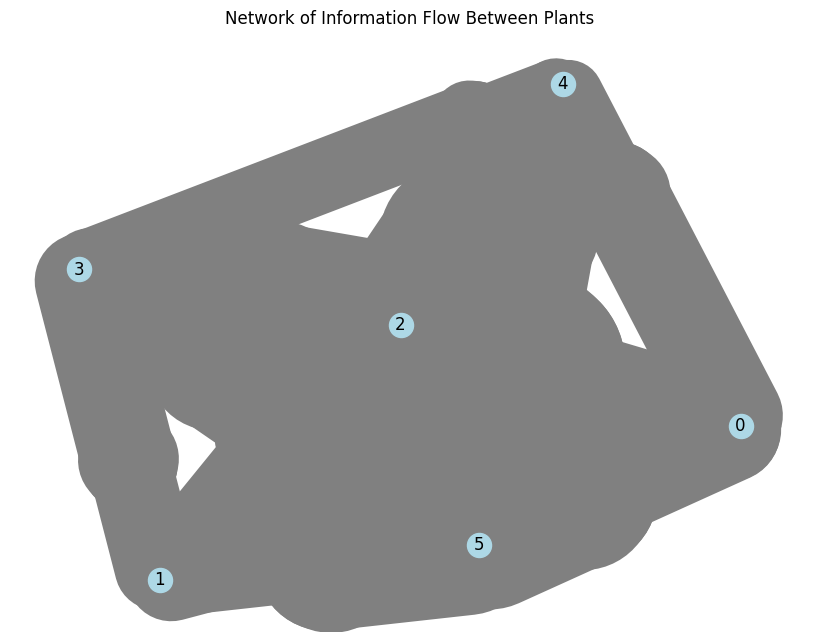

In [ ]:
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# Add edges from df_results
for (plant1, plant2), entropy in df_results.groupby(["Plant1", "Plant2"])["Transfer Entropy"].sum().items():
    if entropy > 0:  # Only include meaningful interactions
        G.add_edge(plant1, plant2, weight=entropy)

# Draw network
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G)  # Layout for positioning nodes
nx.draw(G, pos, with_labels=True, node_color="lightblue", edge_color="gray", width=[d["weight"]*10 for (_, _, d) in G.edges(data=True)])
plt.title("Network of Information Flow Between Plants")
plt.show()


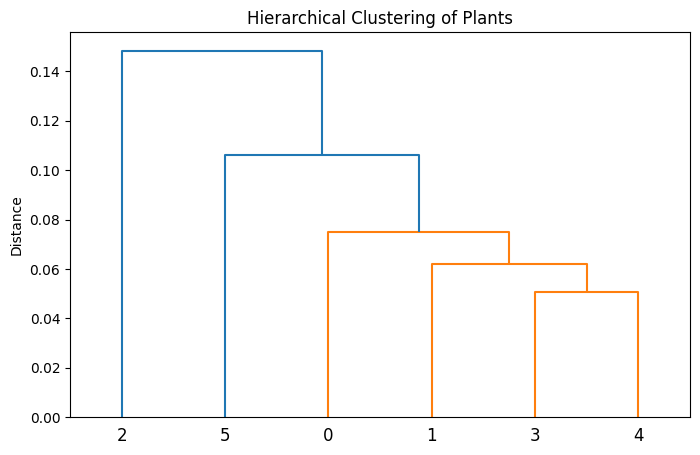

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Pivot table for clustering
df_cluster = df_results.pivot_table(index="Plant1", columns="Plant2", values="Transfer Entropy", fill_value=0)

# Perform clustering
linked = linkage(df_cluster, method="ward")

# Plot dendrogram
plt.figure(figsize=(8, 5))
dendrogram(linked, labels=df_cluster.index, orientation="top")
plt.title("Hierarchical Clustering of Plants")
plt.ylabel("Distance")
plt.show()


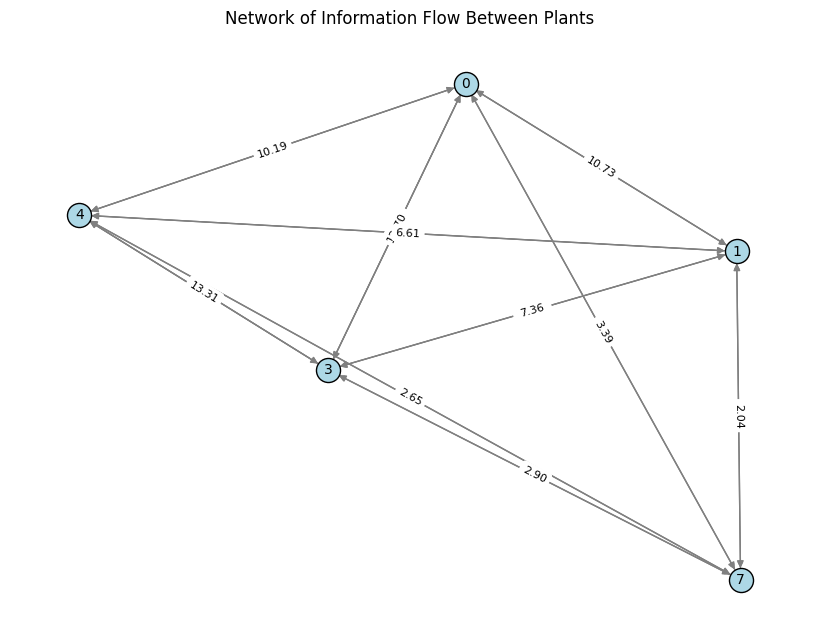

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Add edges for transfer entropy (information flow)
for (plant1, plant2), entropy in df_results.groupby(["Plant1", "Plant2"])["Transfer Entropy"].sum().items():
    if entropy > 0:  # Only include meaningful interactions
        G.add_edge(plant1, plant2, weight=entropy)

# Draw the network
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)  # Layout for positioning nodes
edges = G.edges(data=True)

# Draw nodes
nx.draw(G, pos, with_labels=True, node_color="lightblue", edge_color="gray", font_size=10, edgecolors="black")

# Draw edges with width proportional to entropy
nx.draw_networkx_edges(G, pos, width=[d["weight"] * 0.05 for (_, _, d) in edges], edge_color="gray")

# Add edge labels for transfer entropy values
edge_labels = {(i, j): f"{d['weight']:.2f}" for i, j, d in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("Network of Information Flow Between Plants")
plt.show()

# =============================
# Time-based Analysis: Evolution of Information Flow Over Epochs
# =============================




In [ ]:
df_avg = df_all_seasons_combined.groupby(["Epoch", "Plant1", "Plant2", "Season"])[metric].mean().reset_index()

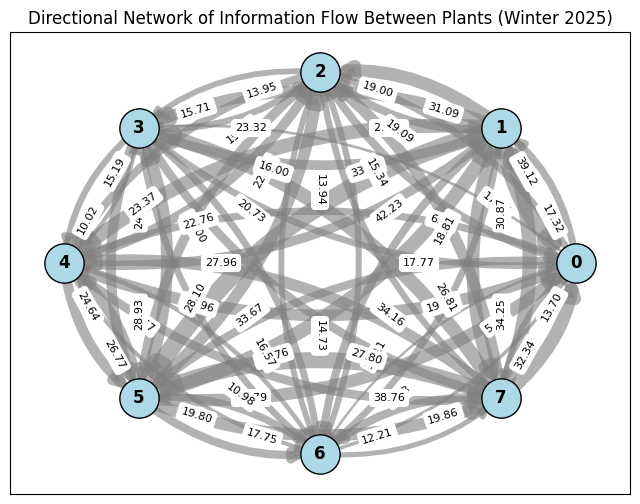

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Add edges for transfer entropy (information flow)
for (plant1, plant2), entropy in df_avg.groupby(["Plant1", "Plant2"])[metric].sum().items():
    if entropy > 0:  # Only include meaningful interactions
        G.add_edge(plant1, plant2, weight=entropy)

# Adjust positions to avoid overlap
pos = nx.circular_layout(G)  # Circular layout reduces edge overlap

# Create figure
plt.figure(figsize=(8, 6))

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color="lightblue", edgecolors="black", node_size=800)

# Draw directional edges with curved arrows to avoid overlap
edge_weights = [d["weight"] * 0.3 for (_, _, d) in G.edges(data=True)]
nx.draw_networkx_edges(G, pos, edgelist=G.edges(), width=edge_weights, alpha=0.6,
                       edge_color="gray", arrows=True, arrowsize=15, connectionstyle="arc3,rad=0.2")

# Draw node labels
nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold")

# Add edge labels (transfer entropy values)
edge_labels = {(i, j): f"{d['weight']:.2f}" for i, j, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, label_pos=0.3)

plt.title("Directional Network of Information Flow Between Plants (Winter 2025)")
plt.show()
